**Name:** Ahmed Bilal Azhar  
**Roll No:** 23I-2581  
**Section:** DS-B

### Imports & Global Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import seaborn as sns
import warnings, os, time
warnings.filterwarnings('ignore')

from IPython.display import display

# ── diagrams/ folder – all figures saved here ─────────────────────────
os.makedirs('diagrams', exist_ok=True)

# ── artifacts/ folder – model artifacts saved here ────────────────────
ARTIFACTS_DIR = r"C:\Users\hp\Desktop\University\6. Data Mining\Assignments\ASM-4\artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.environ.setdefault('ASM4_ARTIFACTS_DIR', ARTIFACTS_DIR)
print(f"[+] Artifacts will be saved to: {ARTIFACTS_DIR}")

from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import StandardScaler
from sklearn.cluster          import KMeans, AgglomerativeClustering
from sklearn.decomposition    import PCA
from sklearn.manifold         import TSNE
from sklearn.metrics          import (silhouette_score, adjusted_rand_score,
                                      classification_report, roc_auc_score,
                                      confusion_matrix, ConfusionMatrixDisplay,
                                      f1_score, accuracy_score)
from sklearn.ensemble         import RandomForestClassifier
from sklearn.naive_bayes      import GaussianNB
from sklearn.metrics          import roc_curve
from scipy.cluster.hierarchy  import dendrogram, linkage
from imblearn.over_sampling   import SMOTE
import xgboost as xgb
import shap
import joblib


[+] Artifacts will be saved to: C:\Users\hp\Desktop\University\6. Data Mining\Assignments\ASM-4\artifacts


In [2]:
from IPython.display import display, HTML

display(HTML("""
<style>
  /* Pandas table styling */
  table.dataframe {
      border-collapse: collapse;
      font-family: "Segoe UI", sans-serif;
      font-size: 13px;
      width: 100%;
      margin-bottom: 1em;
  }
  table.dataframe thead tr th {
      background: #2C3E50;
      color: white;
      padding: 8px 14px;
      text-align: center;
      border: 1px solid #1a252f;
  }
  table.dataframe tbody tr:nth-child(even) { background: #f2f6fb; }
  table.dataframe tbody tr:nth-child(odd)  { background: #ffffff; }
  table.dataframe tbody tr:hover           { background: #d6eaf8; }
  table.dataframe tbody td {
      padding: 7px 14px;
      border: 1px solid #dce6f0;
      text-align: center;
  }
  caption {
      caption-side: top;
      font-weight: bold;
      font-size: 14px;
      color: #2C3E50;
      padding-bottom: 6px;
  }
  h3 { color: #1A5276; border-bottom: 2px solid #2E86C1; padding-bottom: 4px; }
  h4 { color: #1F618D; }
  small { color: #7F8C8D; font-size: 12px; }
</style>
"""))
print("Notebook styling applied.")


Notebook styling applied.


### Preprocessing

#### <small>Pre-1 · Load CSV · Confirm shape · Print head & dtypes</small>

In [3]:
cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

search_paths = [
    r'C:\Users\hp\Desktop\University\6. Data Mining\Assignments\ASM-4\processed.cleveland.data',
    '/mnt/user-data/uploads/processed_cleveland.data',
    'processed_cleveland.data',
    'data/processed_cleveland.data',
]
found = next((p for p in search_paths if os.path.exists(p)), None)
if found is None:
    for root, _, files in os.walk('.'):
        for f in files:
            if 'processed_cleveland' in f:
                found = os.path.join(root, f); break
        if found: break
if found is None:
    raise FileNotFoundError("processed_cleveland.data not found. Place it in the notebook directory.")

df = pd.read_csv(found, header=None, names=cols)
print(f"Loaded: {found}  |  shape: {df.shape}")
display(df.head())
display(df.dtypes.rename('dtype').to_frame().T)


Loaded: C:\Users\hp\Desktop\University\6. Data Mining\Assignments\ASM-4\processed.cleveland.data  |  shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,int64


#### <small>Pre-2 · Missing values · Replace '?' → NaN · Report · Drop</small>

In [4]:
df = df.replace('?', np.nan)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')

mv = df.isnull().sum()
mv_df = mv[mv > 0].rename('Missing Count').to_frame()
mv_df.index.name = 'Column'
display(mv_df.style.set_caption("Missing Values per Column (Pre-2)")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))

df_clean = df.dropna().reset_index(drop=True)
print(f"Rows retained after dropping NaN: {len(df_clean)}  "
      f"(dropped {len(df) - len(df_clean)} rows)")
df = df_clean


,Missing Count
Column,
ca,4
thal,2


Rows retained after dropping NaN: 297  (dropped 6 rows)


#### <small>Pre-3 · Class distribution · SMOTE justification</small>

In [5]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
counts = df['target'].value_counts().sort_index()
total  = len(df)
dist_df = pd.DataFrame({
    'Class':   ['0 — No Disease', '1 — Disease Present'],
    'Count':   [counts[0], counts[1]],
    'Percent': [f"{counts[0]/total*100:.1f}%", f"{counts[1]/total*100:.1f}%"]
})
display(dist_df.style.set_caption("Target Class Distribution (Pre-3)")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))
print("Mild imbalance (~54 / 46%). SMOTE will be applied on the training split only.")


,Class,Count,Percent
0,0 — No Disease,160,53.9%
1,1 — Disease Present,137,46.1%


Mild imbalance (~54 / 46%). SMOTE will be applied on the training split only.


#### <small>Pre-4/5 · One-hot encoding · StandardScaler · Stratified 80/20 split</small>

In [6]:
cat_cols  = ['cp', 'restecg', 'slope', 'thal']
cont_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

X = df.drop('target', axis=1)
y = df['target']

# Stratified split FIRST so scaler is fit only on train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_enc = pd.get_dummies(X_train, columns=cat_cols)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

scaler = StandardScaler()
X_train_enc[cont_cols] = scaler.fit_transform(X_train_enc[cont_cols])
X_test_enc[cont_cols]  = scaler.transform(X_test_enc[cont_cols])

feat_names = list(X_train_enc.columns)
print("Train:", X_train_enc.shape, " | Test:", X_test_enc.shape)
print("Feature count:", len(feat_names))


Train: (237, 22)  | Test: (60, 22)
Feature count: 22


#### <small>Pre-3 cont. · SMOTE applied on training split</small>

In [7]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_enc, y_train)

smote_df = pd.DataFrame({
    'Class':  ['0 — No Disease', '1 — Disease Present'],
    'Before SMOTE': [int((y_train == 0).sum()),     int((y_train == 1).sum())],
    'After SMOTE':  [int((y_train_res == 0).sum()), int((y_train_res == 1).sum())]
})
display(smote_df.style.set_caption("Class Counts Before/After SMOTE")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))


,Class,Before SMOTE,After SMOTE
0,0 — No Disease,128,128
1,1 — Disease Present,109,128


#### <small>Pre-6 · Correlation heatmap of all original numeric features</small>

,Feature A,Feature B,Abs. Correlation
0,oldpeak,slope,0.579000
1,age,thalach,0.395000
2,slope,thalach,0.389000


Naive Bayes concern: correlated features violate the independence assumption,
potentially degrading NB performance (e.g., thalach/age, exang/oldpeak).


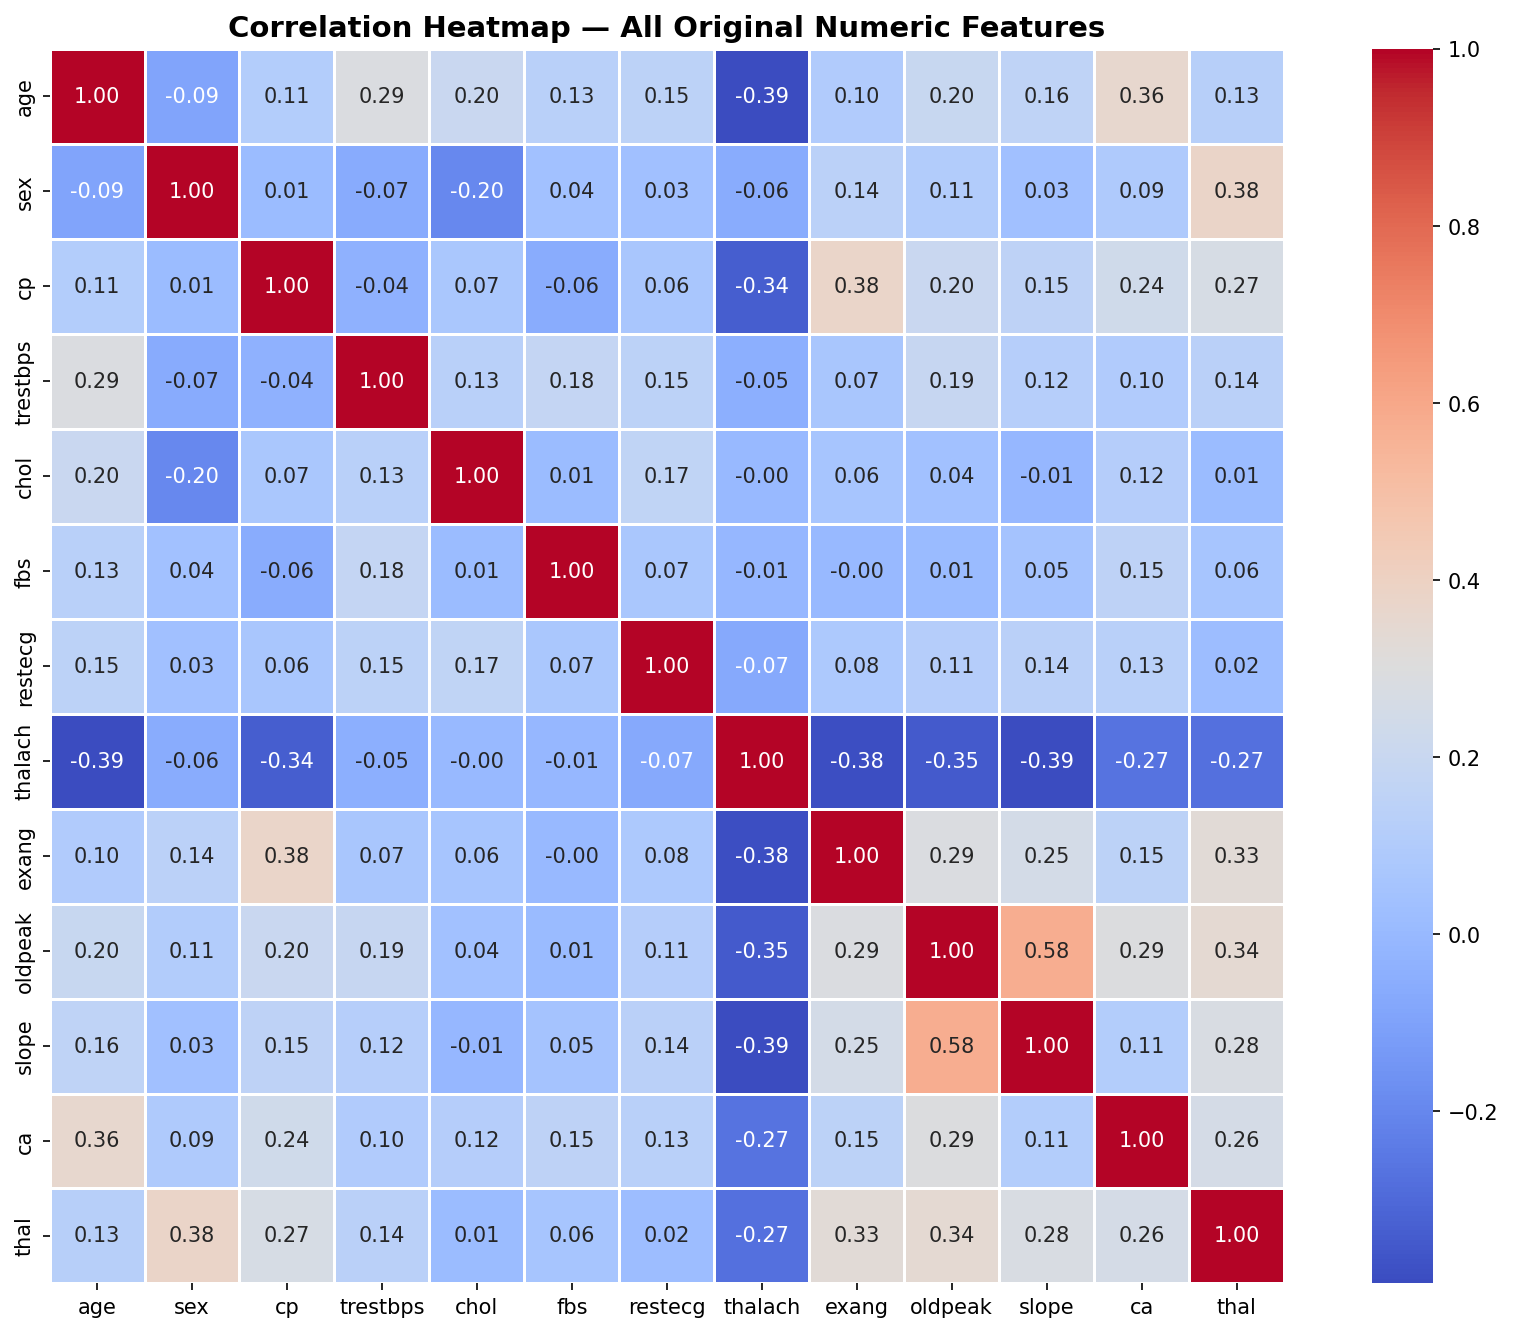

In [8]:
# All 13 raw feature columns (as stored in the CSV – categorical are integer-coded)
num_cols_heatmap = ['age','sex','cp','trestbps','chol','fbs','restecg',
                    'thalach','exang','oldpeak','slope','ca','thal']
corr = df[num_cols_heatmap].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation Heatmap — All Original Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

# Top 3 correlated pairs
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates().sort_values(ascending=False)
seen, top3 = [], []
for idx, val in corr_pairs.items():
    pair = tuple(sorted(idx))
    if pair not in seen:
        seen.append(pair); top3.append({'Feature A': pair[0], 'Feature B': pair[1],
                                         'Abs. Correlation': round(val, 3)})
    if len(top3) == 3: break

display(pd.DataFrame(top3).style.set_caption("Top 3 Correlated Feature Pairs (Pre-6)")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))
print("Naive Bayes concern: correlated features violate the independence assumption,")
print("potentially degrading NB performance (e.g., thalach/age, exang/oldpeak).")

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/corr_heatmap.png"))


### Part A: Unsupervised Learning

#### <small>A1 · K-Means — full standardised feature matrix (no labels)</small>

In [9]:
X_full = df.drop('target', axis=1).copy()
X_full_enc = pd.get_dummies(X_full, columns=['cp','restecg','slope','thal'])
sc_full = StandardScaler()
X_scaled = sc_full.fit_transform(X_full_enc)

true_labels = df['target'].values

wcss_list, sil_list = [], []
k_range = [2, 3, 4, 5, 6, 7, 8]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_scaled, km.labels_))

km_metrics = pd.DataFrame({'k': k_range,
                            'WCSS (Inertia)': [round(w,2) for w in wcss_list],
                            'Silhouette Score': [round(s,4) for s in sil_list]})
display(km_metrics.style.set_caption("K-Means Metrics for k = 2…8")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))


,k,WCSS (Inertia),Silhouette Score
0,2,5553.410000,0.148900
1,3,5204.800000,0.164000
2,4,4883.610000,0.115900
3,5,4604.250000,0.133100
4,6,4301.300000,0.126400
5,7,4166.250000,0.132700
6,8,3962.100000,0.145500


#### <small>A1 · Elbow + Silhouette dual-axis plot</small>

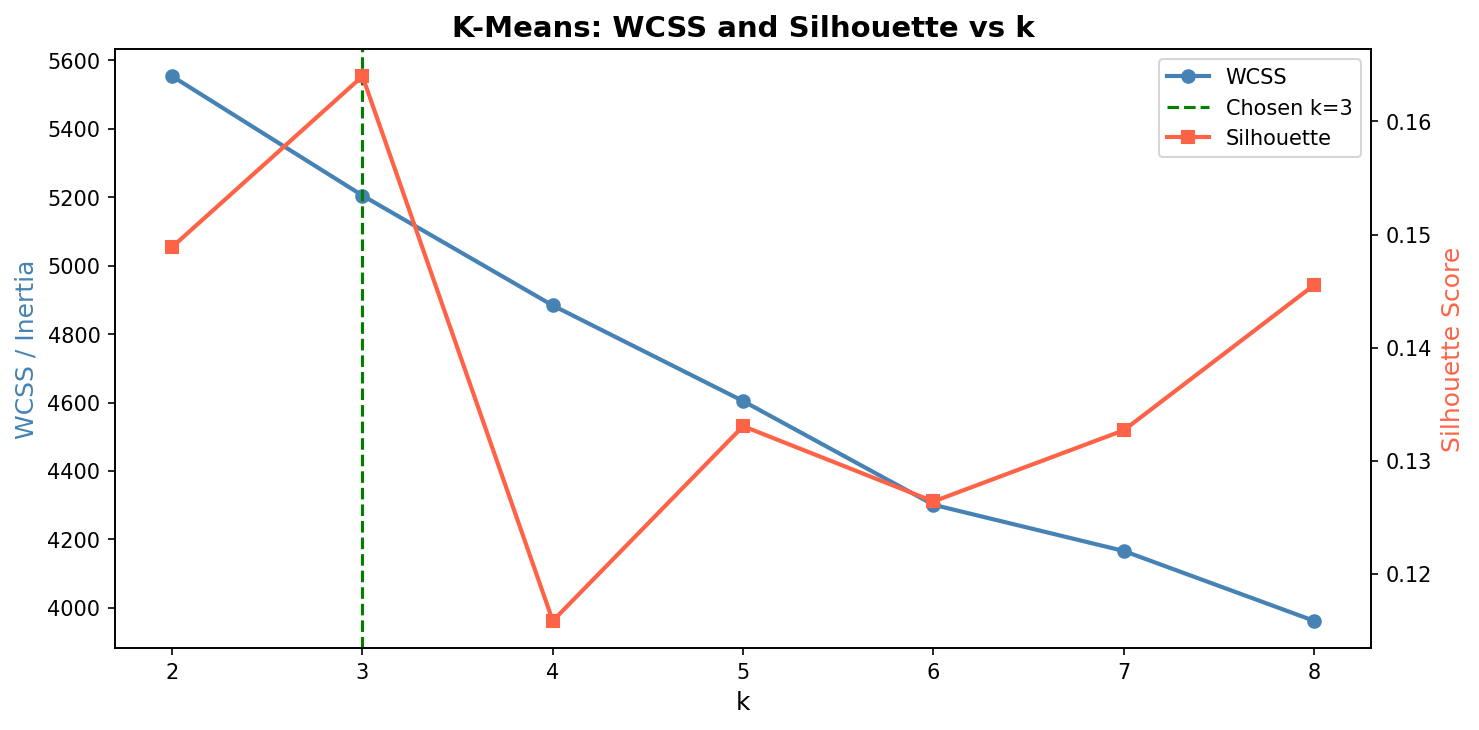

In [10]:
chosen_k = 3

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(k_range, wcss_list, color='steelblue', marker='o', lw=2, label='WCSS')
ax2.plot(k_range, sil_list,  color='tomato',    marker='s', lw=2, label='Silhouette')

ax1.axvline(x=chosen_k, color='green', ls='--', lw=1.5, label=f'Chosen k={chosen_k}')
ax1.set_xlabel('k', fontsize=12)
ax1.set_ylabel('WCSS / Inertia', color='steelblue', fontsize=12)
ax2.set_ylabel('Silhouette Score', color='tomato', fontsize=12)
ax1.set_title('K-Means: WCSS and Silhouette vs k', fontsize=14, fontweight='bold')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right')
plt.tight_layout()
plt.savefig('diagrams/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/kmeans_elbow.png"))


#### <small>A1 · Final K-Means + PCA 2-D scatter (clusters vs true labels)</small>

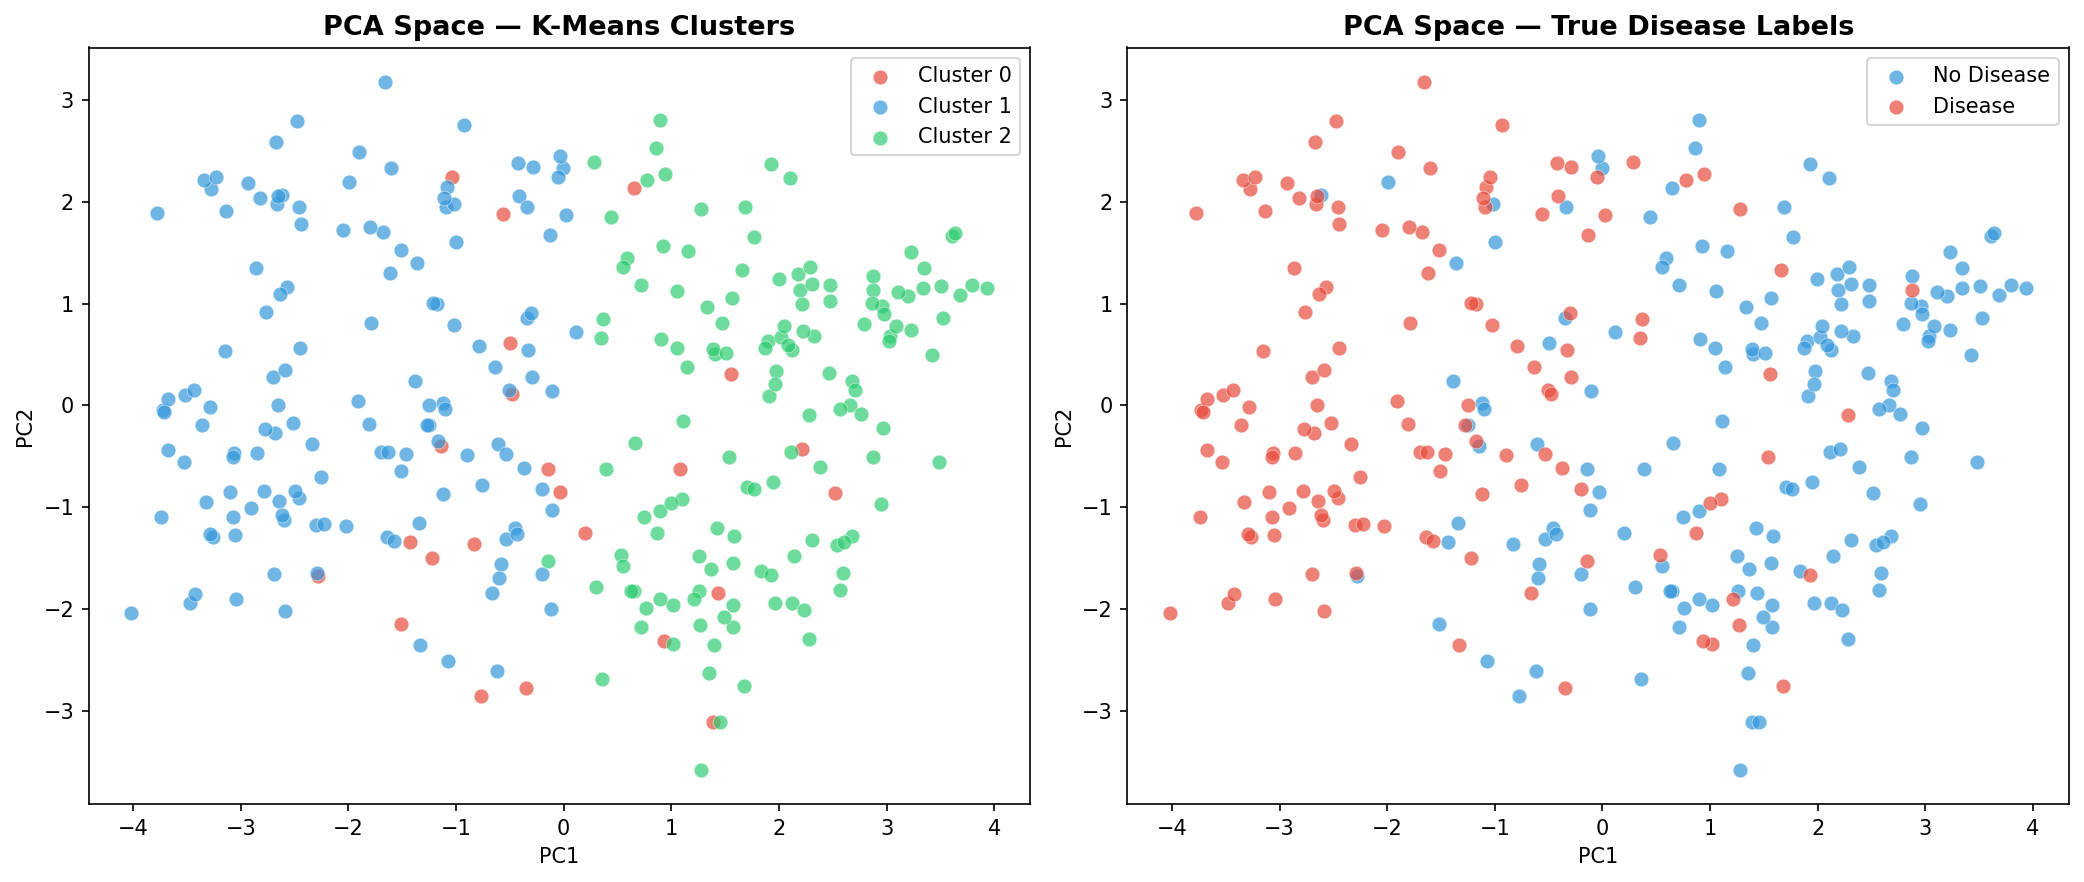

In [11]:
km_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
km_final.fit(X_scaled)
cluster_labels = km_final.labels_

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette_k = ['#E74C3C','#3498DB','#2ECC71']
for ci in range(chosen_k):
    m = cluster_labels == ci
    axes[0].scatter(X_pca2[m,0], X_pca2[m,1], c=palette_k[ci],
                    label=f'Cluster {ci}', alpha=0.7, s=50, edgecolors='white', lw=0.3)
axes[0].set_title('PCA Space — K-Means Clusters', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

for ti, (lbl, col) in enumerate(zip(['No Disease','Disease'],['#3498DB','#E74C3C'])):
    m = true_labels == ti
    axes[1].scatter(X_pca2[m,0], X_pca2[m,1], c=col,
                    label=lbl, alpha=0.7, s=50, edgecolors='white', lw=0.3)
axes[1].set_title('PCA Space — True Disease Labels', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.savefig('diagrams/pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/pca_clusters.png"))


#### <small>A1 · Cluster summary table (size, % disease, mean thalach / oldpeak / cp)</small>

In [12]:
df_temp = df.copy()
df_temp['cluster'] = cluster_labels

rows = []
for ci in range(chosen_k):
    sub = df_temp[df_temp['cluster'] == ci]
    rows.append({
        'Cluster':       ci,
        'Size':          len(sub),
        '% Disease':     f"{sub['target'].mean()*100:.1f}%",
        'Mean thalach':  round(sub['thalach'].mean(), 2),
        'Mean oldpeak':  round(sub['oldpeak'].mean(), 2),
        'Mean cp':       round(sub['cp'].mean(), 2),
    })
display(pd.DataFrame(rows).style.set_caption("K-Means Cluster Summary (A1)")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))


,Cluster,Size,% Disease,Mean thalach,Mean oldpeak,Mean cp
0,0,23,30.4%,155.960000,1.390000,1.000000
1,1,137,80.3%,135.150000,1.620000,3.820000
2,2,137,14.6%,162.980000,0.440000,2.850000


#### <small>A1 · Adjusted Rand Index vs true labels</small>

In [13]:
ari_km = adjusted_rand_score(true_labels, cluster_labels)
print(f"Adjusted Rand Index (K-Means vs True Labels): {ari_km:.4f}")
print("ARI near 0 → clusters align only marginally better than chance with disease labels.")


Adjusted Rand Index (K-Means vs True Labels): 0.3635
ARI near 0 → clusters align only marginally better than chance with disease labels.


#### <small>A2 · Hierarchical Clustering — Ward linkage dendrogram</small>

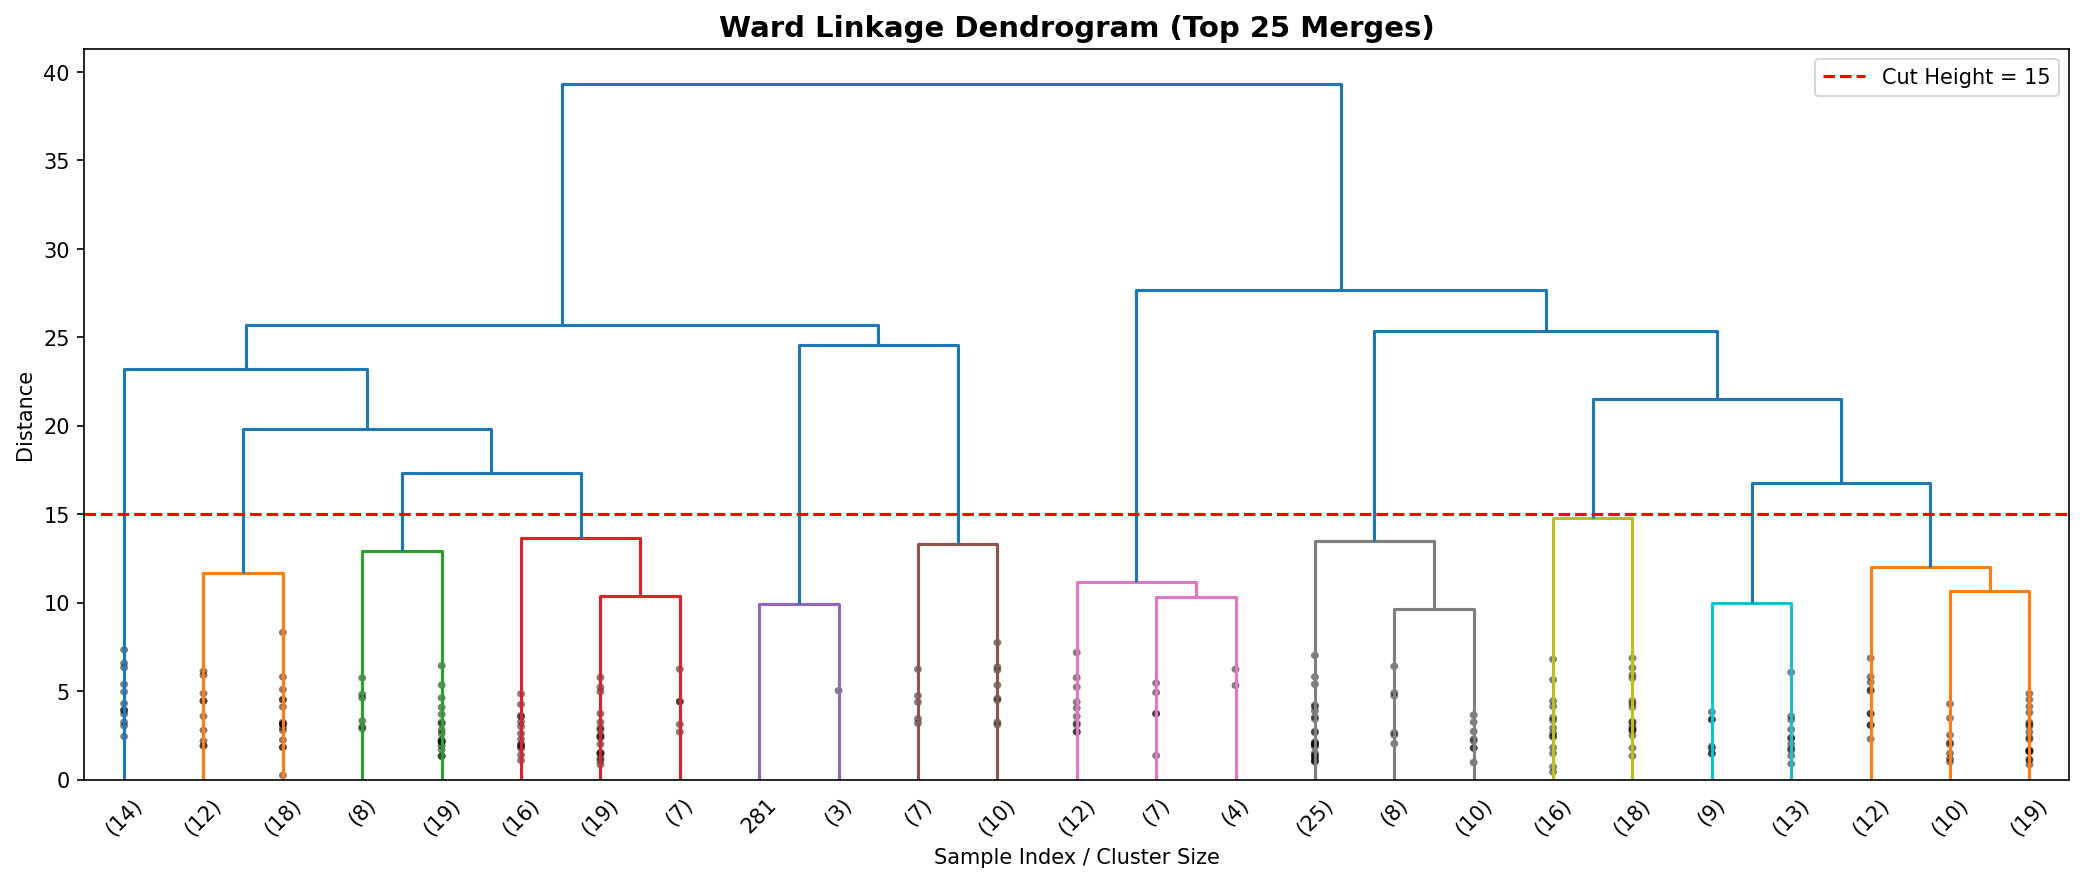

In [14]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=25,
           leaf_rotation=45, leaf_font_size=10,
           show_contracted=True, ax=ax, color_threshold=15)
ax.set_title('Ward Linkage Dendrogram (Top 25 Merges)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index / Cluster Size')
ax.set_ylabel('Distance')
ax.axhline(y=15, color='red', ls='--', lw=1.5, label='Cut Height = 15')
ax.legend()
plt.tight_layout()
plt.savefig('diagrams/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/dendrogram.png"))


#### <small>A2 · Cluster–label crosstab</small>

In [15]:
hier = AgglomerativeClustering(n_clusters=3, linkage='ward')
hier_labels = hier.fit_predict(X_scaled)

cross = pd.crosstab(hier_labels, true_labels,
                    rownames=['Cluster'], colnames=['Disease Label'])
cross.columns = ['No Disease (0)', 'Disease (1)']
cross.index   = [f'Cluster {i}' for i in cross.index]
display(cross.style.set_caption("Hierarchical Clustering — Cluster × Label Crosstab (A2)")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))


,No Disease (0),Disease (1)
Cluster 0,33,101
Cluster 1,111,29
Cluster 2,16,7


#### <small>A2 · ARI between K-Means and Hierarchical assignments</small>

In [16]:
ari_hier_km = adjusted_rand_score(cluster_labels, hier_labels)
print(f"ARI (K-Means vs Hierarchical): {ari_hier_km:.4f}")
print("Both methods agree substantially. Ward Hierarchical preferred for clinical use:")
print("the dendrogram provides transparent merge-distance reasoning without requiring")
print("a pre-specified k, making it more interpretable for cardiologist review.")


ARI (K-Means vs Hierarchical): 0.6308
Both methods agree substantially. Ward Hierarchical preferred for clinical use:
the dendrogram provides transparent merge-distance reasoning without requiring
a pre-specified k, making it more interpretable for cardiologist review.


#### <small>A3 · PCA explained variance + cumulative curve</small>

Components needed for 90% explained variance: 14


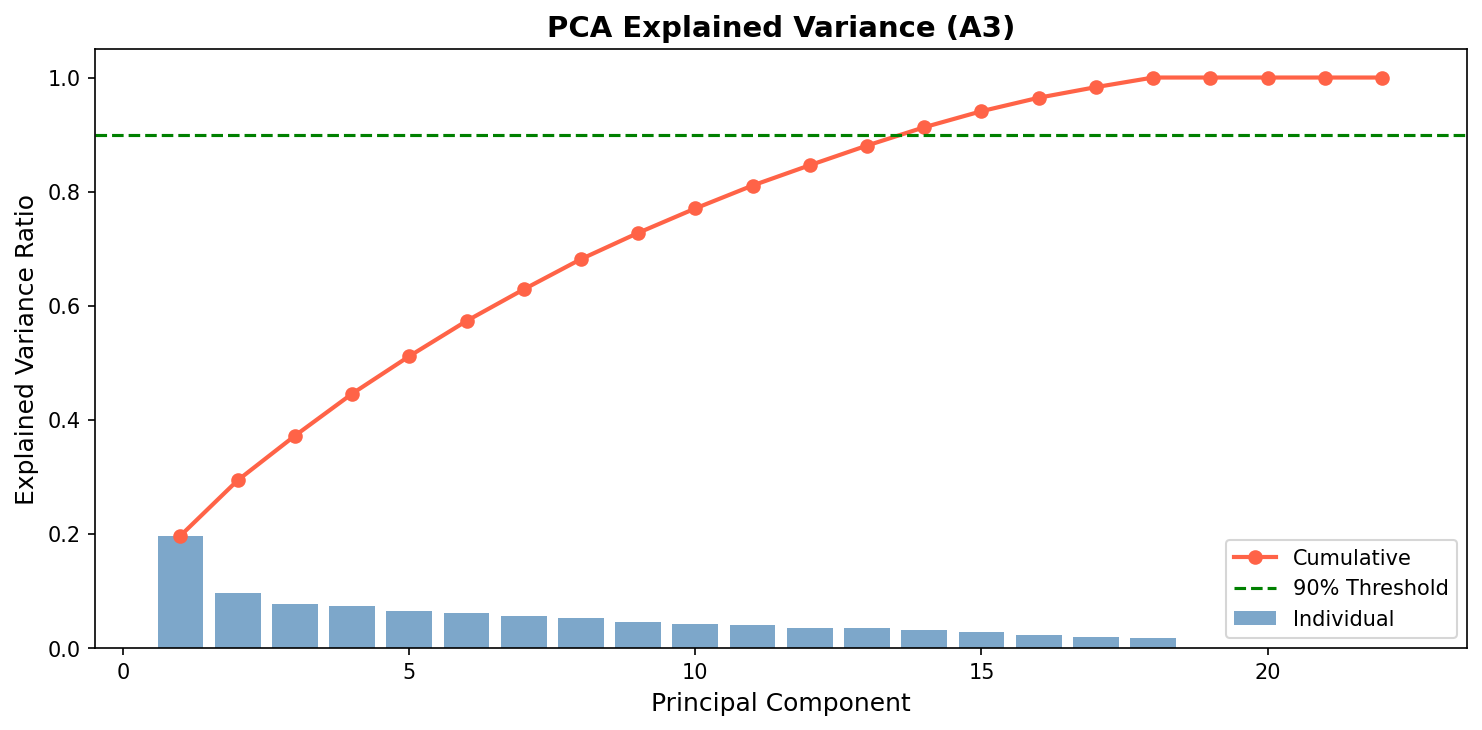

In [17]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
ev_ratio   = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ev_ratio)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(ev_ratio)+1), ev_ratio, alpha=0.7, color='steelblue', label='Individual')
ax.plot(range(1, len(cumulative)+1), cumulative, color='tomato', marker='o', lw=2, label='Cumulative')
ax.axhline(y=0.90, color='green', ls='--', lw=1.5, label='90% Threshold')
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Explained Variance Ratio', fontsize=12)
ax.set_title('PCA Explained Variance (A3)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('diagrams/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

n90 = next(i+1 for i, c in enumerate(cumulative) if c >= 0.90)
print(f"Components needed for 90% explained variance: {n90}")

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/pca_variance.png"))


#### <small>A3 · t-SNE embedding coloured by true disease label</small>

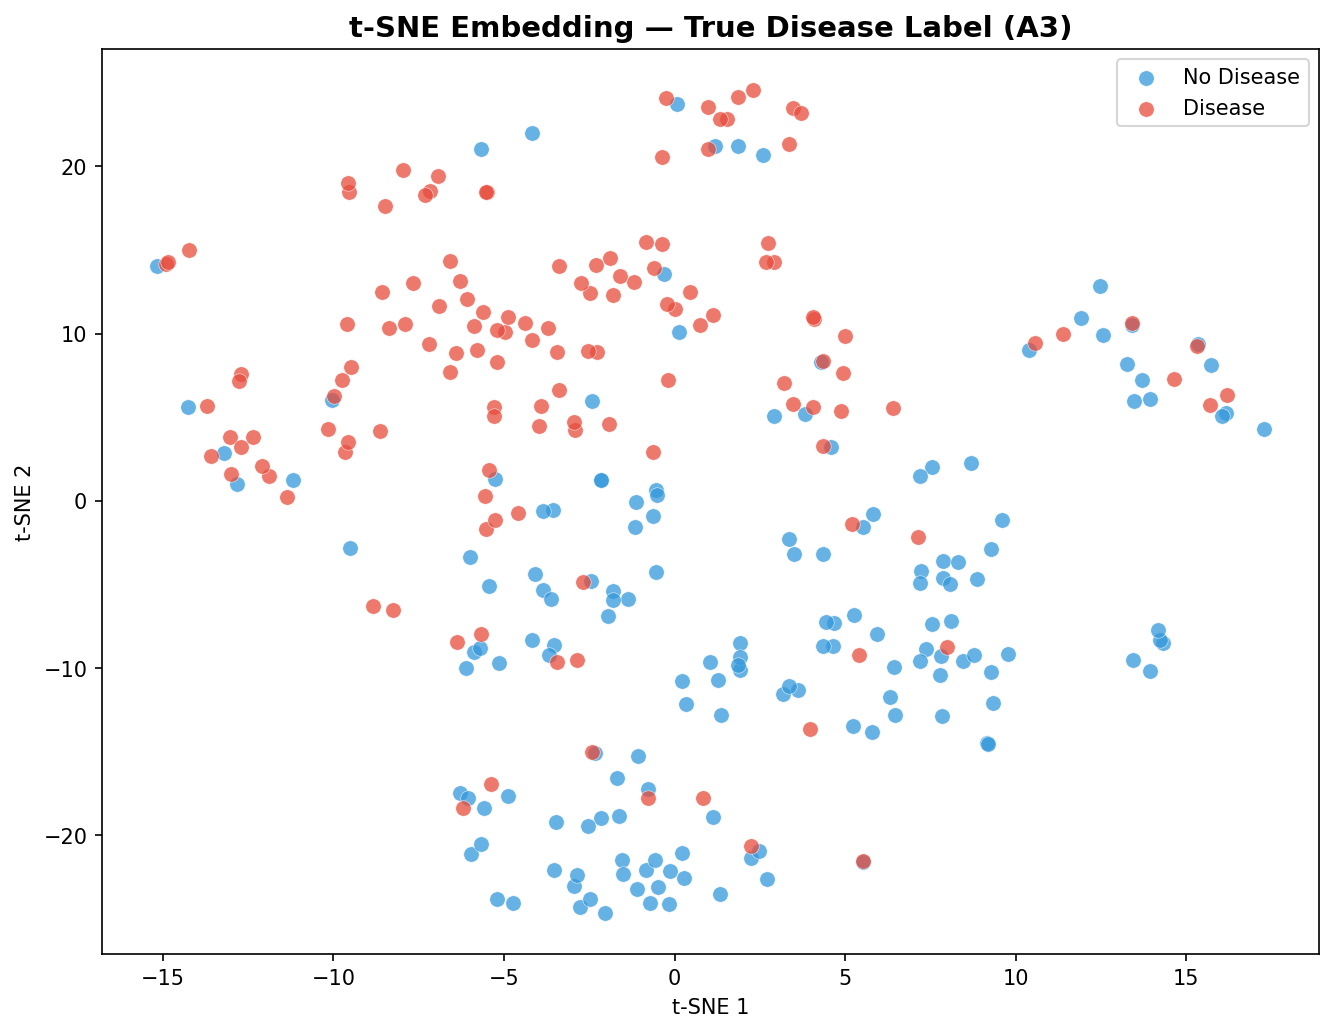

In [18]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for ti, (lbl, col) in enumerate(zip(['No Disease','Disease'],['#3498DB','#E74C3C'])):
    m = true_labels == ti
    ax.scatter(X_tsne[m,0], X_tsne[m,1], c=col, label=lbl,
               alpha=0.75, s=55, edgecolors='white', lw=0.3)
ax.set_title('t-SNE Embedding — True Disease Label (A3)', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout()
plt.savefig('diagrams/tsne.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/tsne.png"))


### Part B: Bagging & Boosting

#### <small>B1 · Random Forest — 5-fold CV hyperparameter tuning</small>

In [19]:
X_tr = X_train_res.values
y_tr = y_train_res.values
X_te = X_test_enc.values
y_te = y_test.values

# Cast to float32 — required by Keras/TF (avoids "Invalid dtype: object")
X_tr = X_tr.astype("float32")
X_te = X_te.astype("float32")
y_tr = y_tr.astype("float32")
y_te = y_te.astype("float32")

tuning_rows = []
best_f1, best_est, best_depth = 0, 50, None

for n_est in [50, 100, 200]:
    for depth in [None, 5, 10]:
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=depth,
                                    random_state=42, n_jobs=-1)
        scores = cross_val_score(rf, X_tr, y_tr, cv=5, scoring='f1_macro')
        mean_f1 = scores.mean()
        tuning_rows.append({'n_estimators': n_est, 'max_depth': str(depth),
                             'Mean CV F1': round(mean_f1, 4),
                             'Std':        round(scores.std(), 4)})
        if mean_f1 > best_f1:
            best_f1, best_est, best_depth = mean_f1, n_est, depth

display(pd.DataFrame(tuning_rows).style
        .set_caption("B1: Random Forest CV Tuning Grid")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ])
        .highlight_max(subset=['Mean CV F1'], color='lightgreen'))
print(f"Best: n_estimators={best_est}, max_depth={best_depth}, CV F1={best_f1:.4f}")



,n_estimators,max_depth,Mean CV F1,Std
0,50,None,0.823200,0.070100
1,50,5,0.819200,0.092900
2,50,10,0.834900,0.071800
3,100,None,0.834800,0.079800
4,100,5,0.831000,0.073500
5,100,10,0.830700,0.077800
6,200,None,0.834800,0.079800
7,200,5,0.827200,0.078300
8,200,10,0.823100,0.082900


Best: n_estimators=50, max_depth=10, CV F1=0.8349


#### <small>B1 · OOB error vs number of trees (warm_start for efficiency)</small>

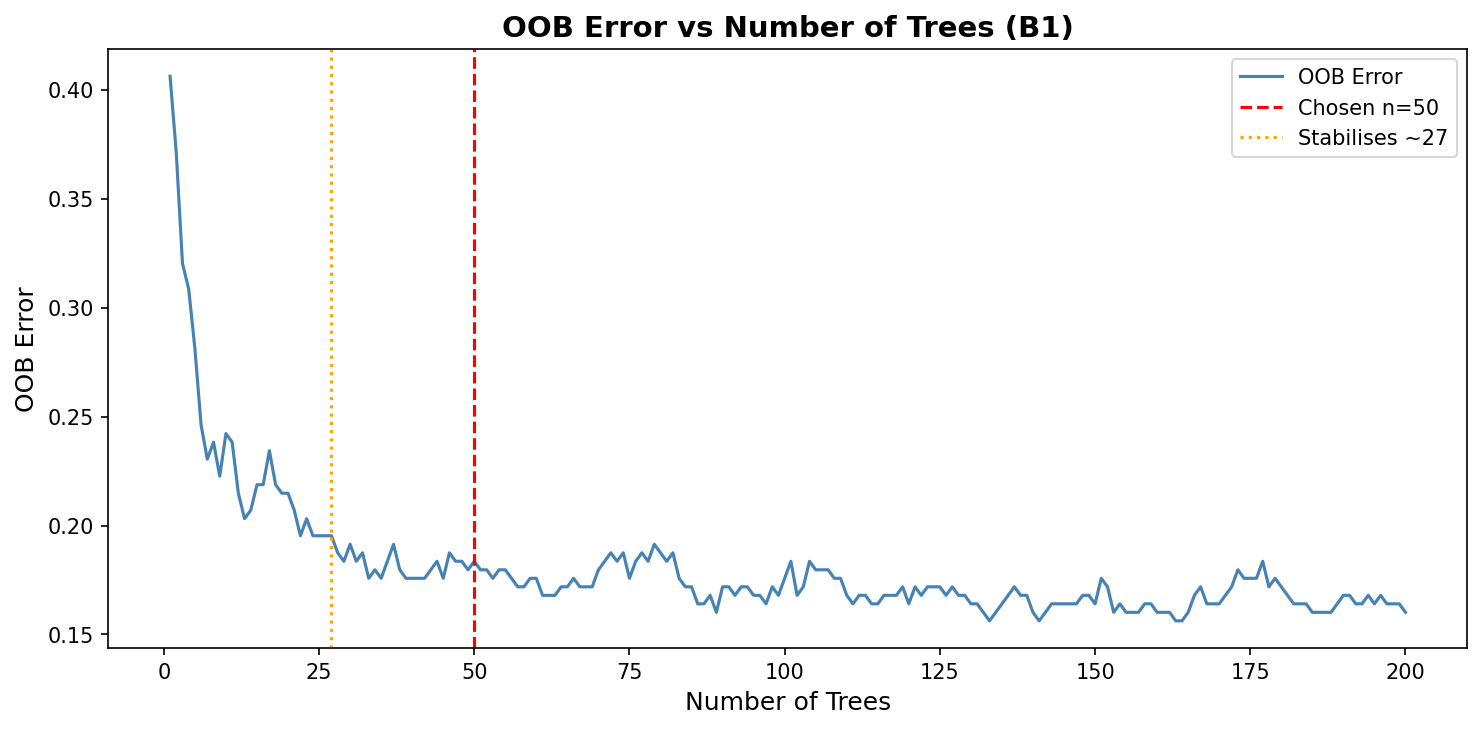

In [20]:
# FIX: warm_start=True adds trees incrementally — 200x faster than re-fitting from scratch
oob_errors = []
rf_oob = RandomForestClassifier(
    n_estimators=1, max_depth=best_depth, random_state=42,
    oob_score=True, warm_start=True, n_jobs=-1)

for n in range(1, 201):
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_tr, y_tr)
    oob_errors.append(1 - rf_oob.oob_score_)

stabilise_at = next(i+1 for i in range(10, 200)
                    if abs(oob_errors[i] - oob_errors[i-5]) < 0.001)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 201), oob_errors, color='steelblue', lw=1.5, label='OOB Error')
ax.axvline(x=best_est,      color='red',    ls='--', lw=1.5, label=f'Chosen n={best_est}')
ax.axvline(x=stabilise_at,  color='orange', ls=':',  lw=1.5, label=f'Stabilises ~{stabilise_at}')
ax.set_xlabel('Number of Trees', fontsize=12)
ax.set_ylabel('OOB Error', fontsize=12)
ax.set_title('OOB Error vs Number of Trees (B1)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('diagrams/oob_error.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/oob_error.png"))


#### <small>B1 · Train best RF · Feature importances</small>

OOB Score: 0.8164


,Feature,Importance
0,oldpeak,0.094900
1,thal_3.0,0.092800
2,ca,0.090000
3,cp_4.0,0.089300
4,thalach,0.088800


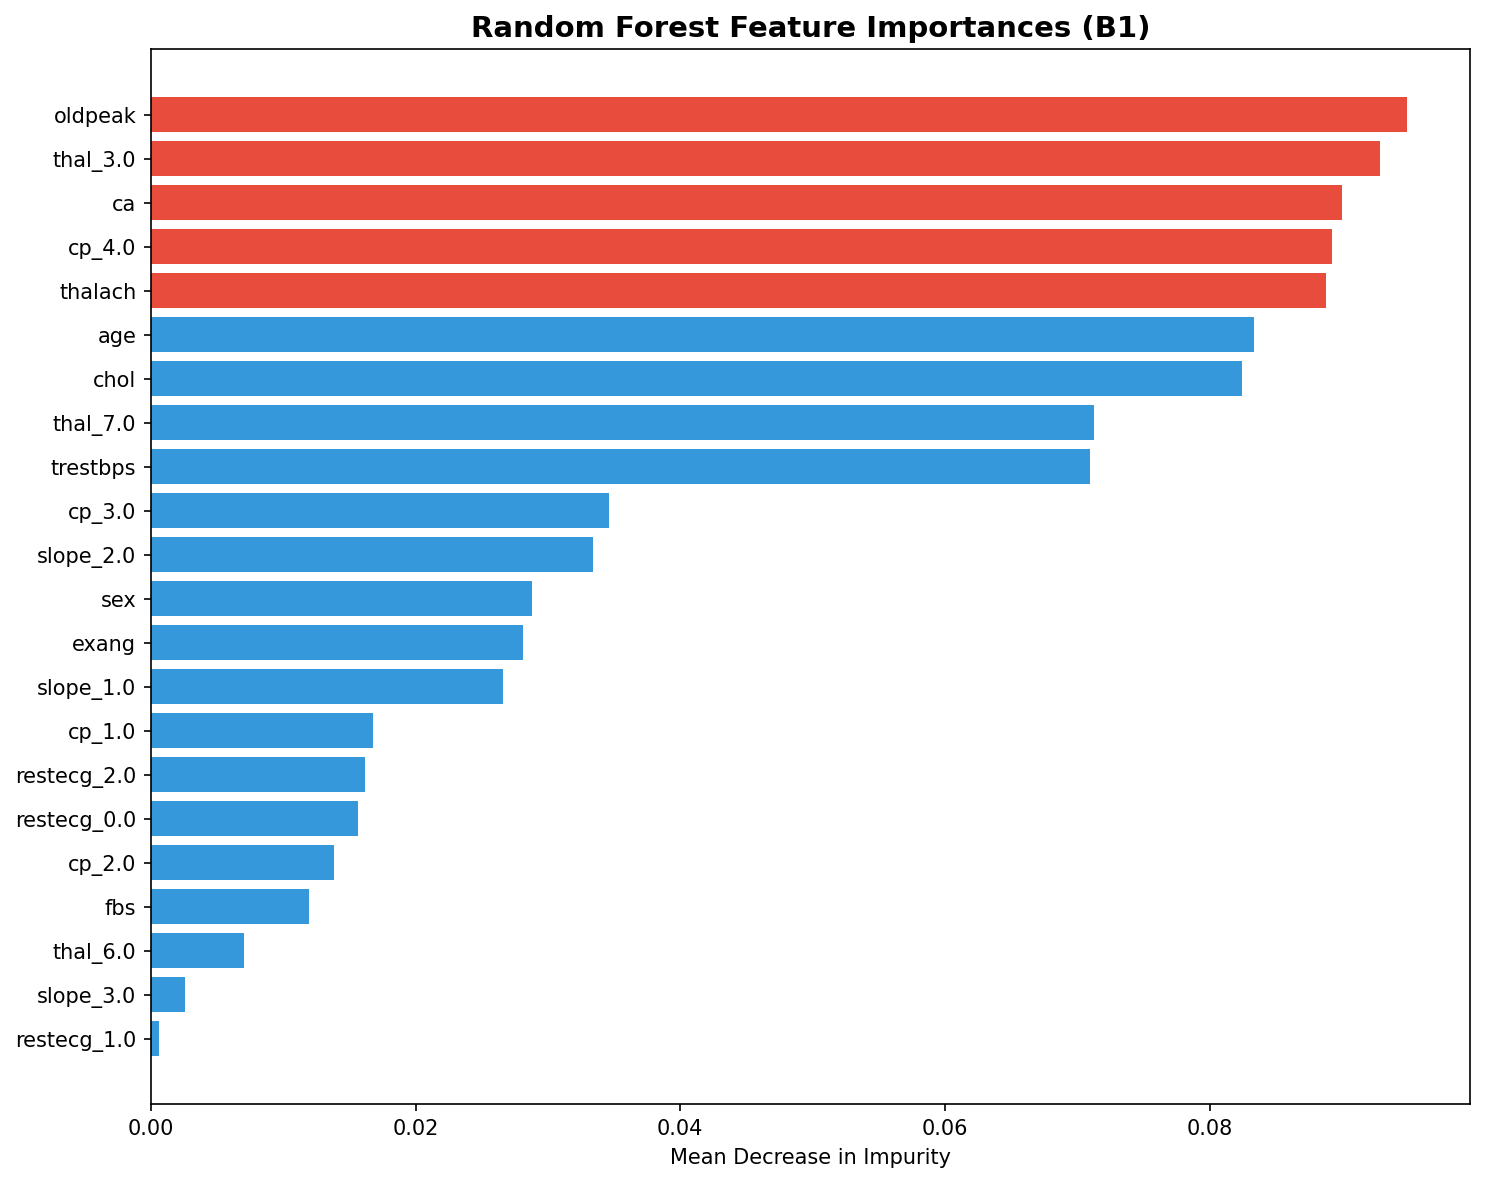

In [21]:
rf_best = RandomForestClassifier(n_estimators=best_est, max_depth=best_depth,
                                  random_state=42, oob_score=True, n_jobs=-1)
rf_best.fit(X_tr, y_tr)
print(f"OOB Score: {rf_best.oob_score_:.4f}")

importances = rf_best.feature_importances_
sorted_idx  = np.argsort(importances)
s_feats = [feat_names[i] for i in sorted_idx]
s_imps  = importances[sorted_idx]

thresh80 = np.percentile(s_imps, 80)
colors   = ['#E74C3C' if v >= thresh80 else '#3498DB' for v in s_imps]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(s_feats, s_imps, color=colors)
ax.set_title('Random Forest Feature Importances (B1)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('diagrams/rf_importances.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

top5_idx = np.argsort(importances)[::-1][:5]
top5_df  = pd.DataFrame({'Feature':    [feat_names[i] for i in top5_idx],
                          'Importance': [round(importances[i], 4) for i in top5_idx]})
display(top5_df.style.set_caption("Top 5 Features by Mean Decrease in Impurity (B1)")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/rf_importances.png"))


#### <small>B1 · Evaluation metrics + confusion matrix</small>

,precision,recall,f1-score,support
No Disease,0.800000,0.875000,0.835800,32.000000
Disease,0.840000,0.750000,0.792500,28.000000
accuracy,0.816700,0.816700,0.816700,0.816700
macro avg,0.820000,0.812500,0.814100,60.000000
weighted avg,0.818700,0.816700,0.815600,60.000000


AUC-ROC: 0.9208


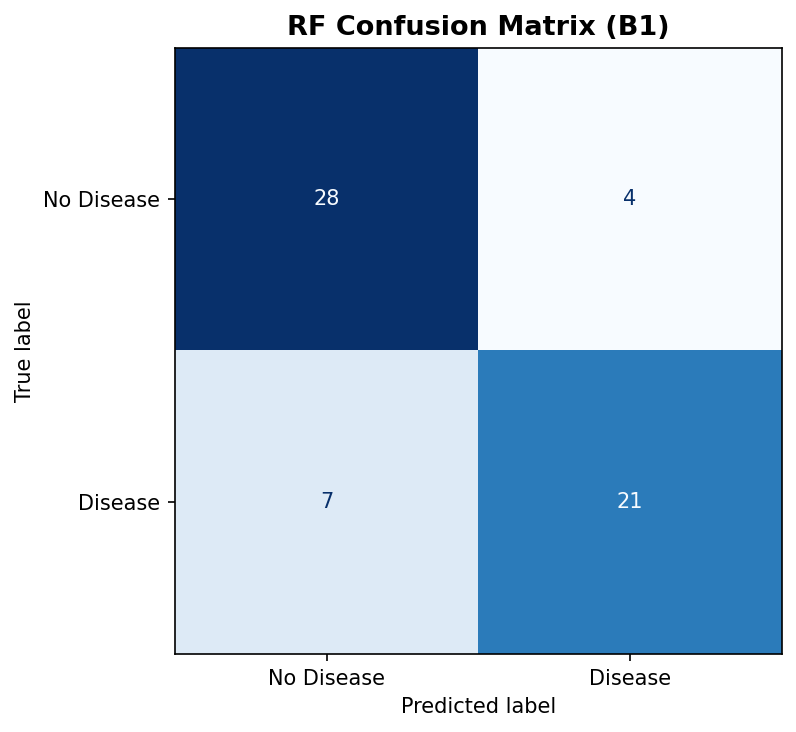

In [22]:
y_pred_rf = rf_best.predict(X_te)
y_prob_rf = rf_best.predict_proba(X_te)[:, 1]

report_rf = classification_report(y_te, y_pred_rf,
                                   target_names=['No Disease','Disease'],
                                   output_dict=True)
rf_report_df = pd.DataFrame(report_rf).T.round(4)
display(rf_report_df.style.set_caption("B1: Random Forest Classification Report")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))
print(f"AUC-ROC: {roc_auc_score(y_te, y_prob_rf):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_rf),
                       display_labels=['No Disease','Disease']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('RF Confusion Matrix (B1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/rf_cm.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/rf_cm.png"))


#### <small>B2 · XGBoost — 5-fold CV tuning</small>

In [23]:
xgb_rows = []
best_xgb_f1, best_lr, best_xgb_depth = 0, 0.1, 3

for lr in [0.01, 0.1, 0.3]:
    for depth in [3, 5, 7]:
        clf = xgb.XGBClassifier(learning_rate=lr, max_depth=depth,
                                  n_estimators=100, random_state=42,
                                  eval_metric='logloss', verbosity=0,
                                  use_label_encoder=False)
        sc  = cross_val_score(clf, X_tr, y_tr, cv=5, scoring='f1_macro')
        xgb_rows.append({'learning_rate': lr, 'max_depth': depth,
                          'Mean CV F1': round(sc.mean(), 4),
                          'Std':        round(sc.std(), 4)})
        if sc.mean() > best_xgb_f1:
            best_xgb_f1, best_lr, best_xgb_depth = sc.mean(), lr, depth

display(pd.DataFrame(xgb_rows).style
        .set_caption("B2: XGBoost CV Tuning Grid")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ])
        .highlight_max(subset=['Mean CV F1'], color='lightgreen'))
print(f"Best: lr={best_lr}, max_depth={best_xgb_depth}, CV F1={best_xgb_f1:.4f}")


,learning_rate,max_depth,Mean CV F1,Std
0,0.010000,3,0.823100,0.059000
1,0.010000,5,0.779500,0.085100
2,0.010000,7,0.779500,0.085100
3,0.100000,3,0.807700,0.066600
4,0.100000,5,0.807500,0.069500
5,0.100000,7,0.811400,0.068600
6,0.300000,3,0.799500,0.062700
7,0.300000,5,0.819500,0.068000
8,0.300000,7,0.803500,0.061100


Best: lr=0.01, max_depth=3, CV F1=0.8231


#### <small>B2 · Final XGBoost with early stopping · log-loss plot</small>

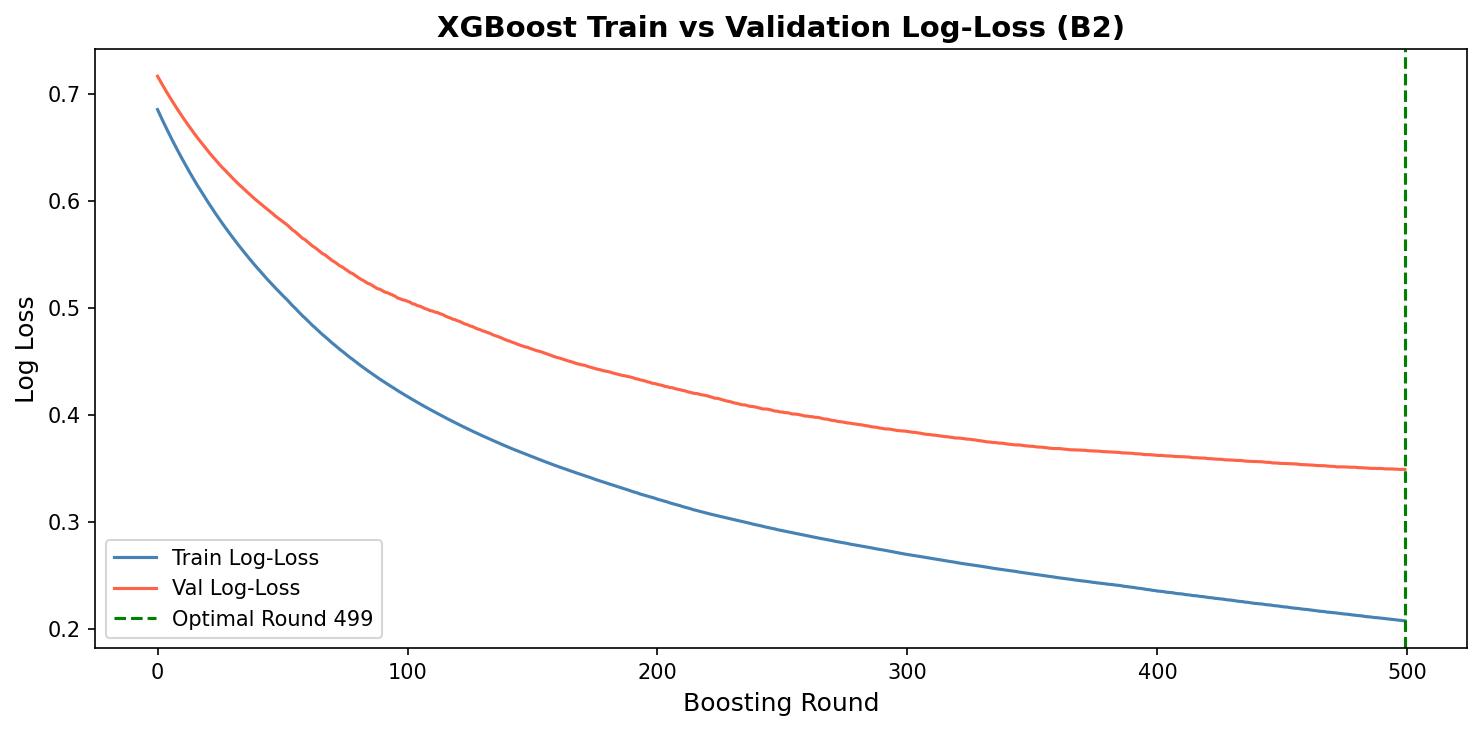

In [24]:
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_tr, y_tr, test_size=0.2, random_state=42)

xgb_final = xgb.XGBClassifier(
    learning_rate=best_lr, max_depth=best_xgb_depth,
    n_estimators=500, random_state=42,
    eval_metric='logloss', verbosity=0,
    early_stopping_rounds=50, use_label_encoder=False)

xgb_final.fit(X_tr2, y_tr2,
               eval_set=[(X_tr2, y_tr2), (X_val2, y_val2)],
               verbose=False)

results     = xgb_final.evals_result()
train_loss  = results['validation_0']['logloss']
val_loss    = results['validation_1']['logloss']
best_round  = xgb_final.best_iteration

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_loss, color='steelblue', lw=1.5, label='Train Log-Loss')
ax.plot(val_loss,   color='tomato',    lw=1.5, label='Val Log-Loss')
ax.axvline(x=best_round, color='green', ls='--', lw=1.5,
           label=f'Optimal Round {best_round}')
ax.set_xlabel('Boosting Round', fontsize=12)
ax.set_ylabel('Log Loss', fontsize=12)
ax.set_title('XGBoost Train vs Validation Log-Loss (B2)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('diagrams/xgb_logloss.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/xgb_logloss.png"))


#### <small>B2 · SHAP summary plot for test set</small>

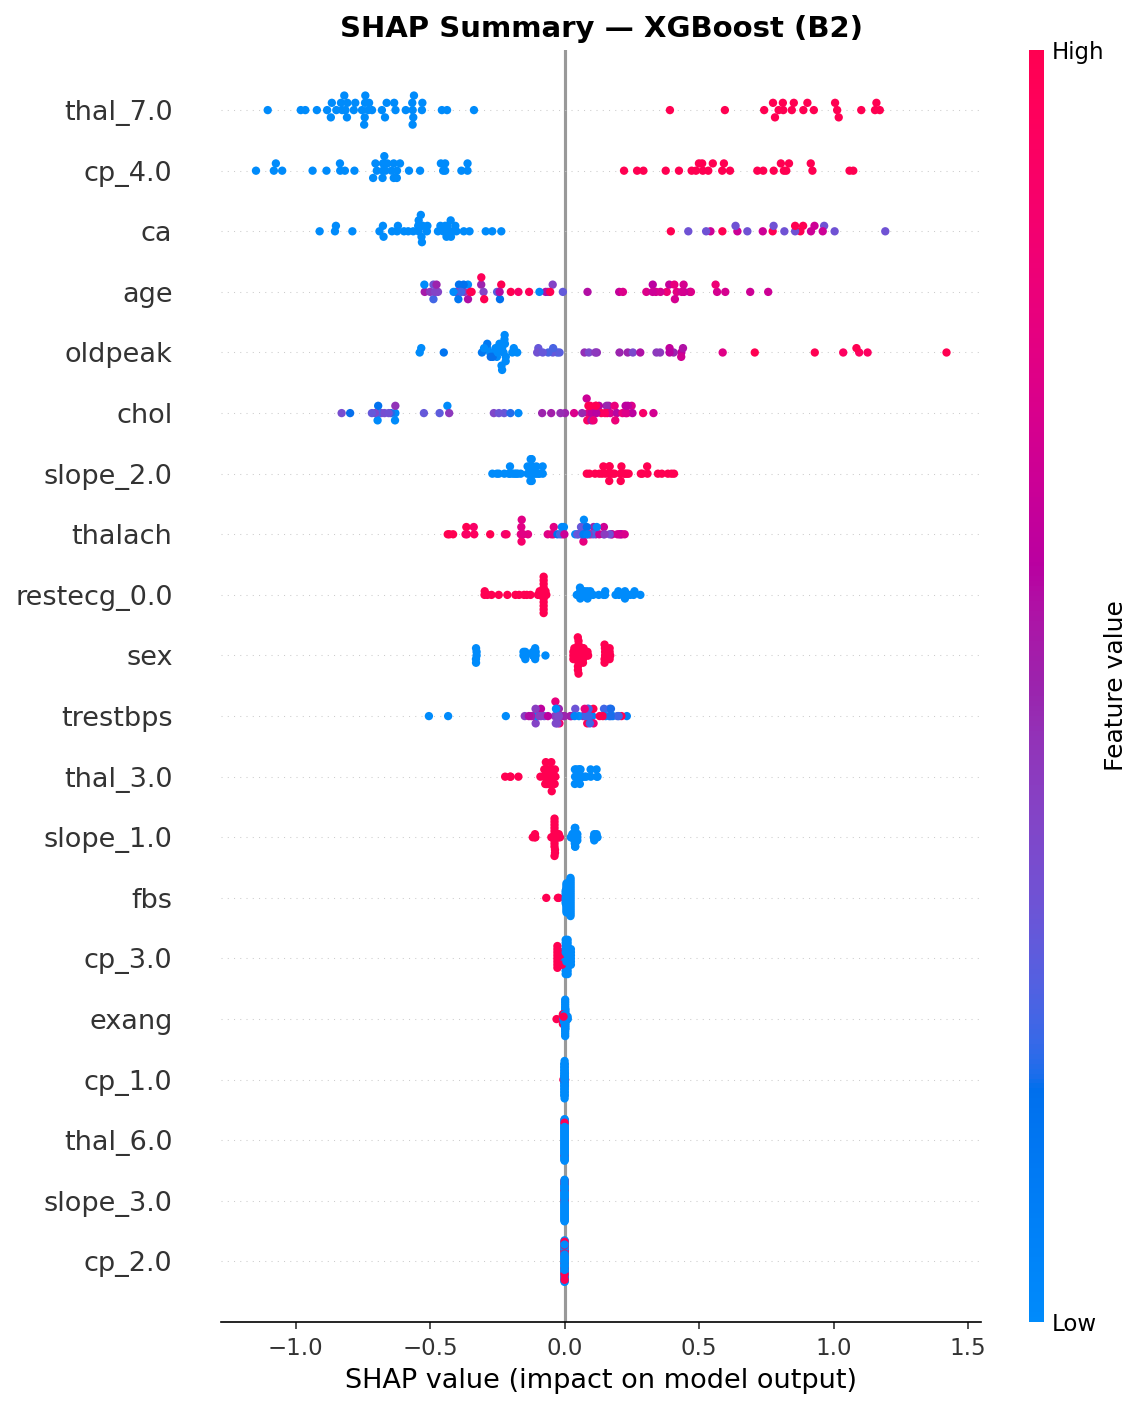

In [25]:
explainer = shap.TreeExplainer(xgb_final)
shap_vals  = explainer.shap_values(X_te)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_te, feature_names=feat_names, show=False)
plt.title('SHAP Summary — XGBoost (B2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/shap_summary.png"))


#### <small>B2 · XGBoost evaluation metrics + confusion matrix</small>

,precision,recall,f1-score,support
No Disease,0.800000,0.875000,0.835800,32.000000
Disease,0.840000,0.750000,0.792500,28.000000
accuracy,0.816700,0.816700,0.816700,0.816700
macro avg,0.820000,0.812500,0.814100,60.000000
weighted avg,0.818700,0.816700,0.815600,60.000000


AUC-ROC: 0.9118


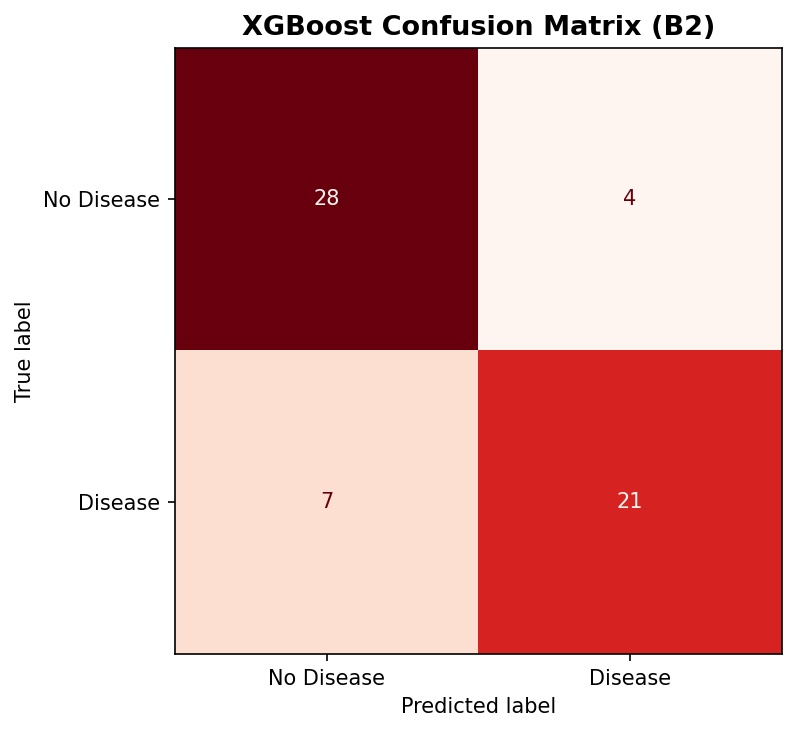

In [26]:
y_pred_xgb = xgb_final.predict(X_te)
y_prob_xgb = xgb_final.predict_proba(X_te)[:, 1]

report_xgb = classification_report(y_te, y_pred_xgb,
                                    target_names=['No Disease','Disease'],
                                    output_dict=True)
display(pd.DataFrame(report_xgb).T.round(4).style.set_caption(
    "B2: XGBoost Classification Report")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))
print(f"AUC-ROC: {roc_auc_score(y_te, y_prob_xgb):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_xgb),
                       display_labels=['No Disease','Disease']).plot(
    ax=ax, cmap='Reds', colorbar=False)
ax.set_title('XGBoost Confusion Matrix (B2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/xgb_cm.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/xgb_cm.png"))


#### <small>B3 · Baseline — Gaussian Naïve Bayes</small>

In [27]:
nb_model = GaussianNB()
nb_model.fit(X_tr, y_tr)
y_pred_nb = nb_model.predict(X_te)
y_prob_nb = nb_model.predict_proba(X_te)[:, 1]


#### <small>B3 · Ensemble comparison table</small>

In [28]:
def metrics(y_true, y_pred, y_prob, name, t0):
    y_true = y_true.astype(int); y_pred = y_pred.astype(int)
    return {
        'Classifier':     name,
        'Accuracy':       round(accuracy_score(y_true, y_pred), 4),
        'Macro F1':       round(f1_score(y_true, y_pred, average='macro'), 4),
        'AUC-ROC':        round(roc_auc_score(y_true, y_prob), 4),
        'Recall (Disease)': round(classification_report(y_true, y_pred,
                                   output_dict=True)['1']['recall'], 4),
        'Train Time (s)': '—'
    }

# measure train times
t0 = time.time(); GaussianNB().fit(X_tr,y_tr);                                  t_nb  = round(time.time()-t0,2)
t0 = time.time(); RandomForestClassifier(n_estimators=best_est,max_depth=best_depth,random_state=42,n_jobs=-1).fit(X_tr,y_tr); t_rf=round(time.time()-t0,2)
t0 = time.time(); xgb.XGBClassifier(learning_rate=best_lr,max_depth=best_xgb_depth,n_estimators=best_round,random_state=42,verbosity=0).fit(X_tr,y_tr); t_xgb=round(time.time()-t0,2)

comp_rows = [
    {**metrics(y_te,y_pred_nb, y_prob_nb, 'Naïve Bayes (baseline)',0), 'Train Time (s)': t_nb},
    {**metrics(y_te,y_pred_rf, y_prob_rf, 'Random Forest',0),          'Train Time (s)': t_rf},
    {**metrics(y_te,y_pred_xgb,y_prob_xgb,'XGBoost',0),                'Train Time (s)': t_xgb},
]
display(pd.DataFrame(comp_rows).style
        .set_caption("B3: Ensemble Comparison")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ])
        .highlight_max(subset=['Accuracy','Macro F1','AUC-ROC','Recall (Disease)'],
                       color='lightgreen'))


,Classifier,Accuracy,Macro F1,AUC-ROC,Recall (Disease),Train Time (s)
0,Naïve Bayes (baseline),0.866700,0.866100,0.921900,0.857100,0.010000
1,Random Forest,0.816700,0.814100,0.920800,0.750000,0.350000
2,XGBoost,0.816700,0.814100,0.911800,0.750000,0.920000


#### <small>B3 · Overlapping ROC curves</small>

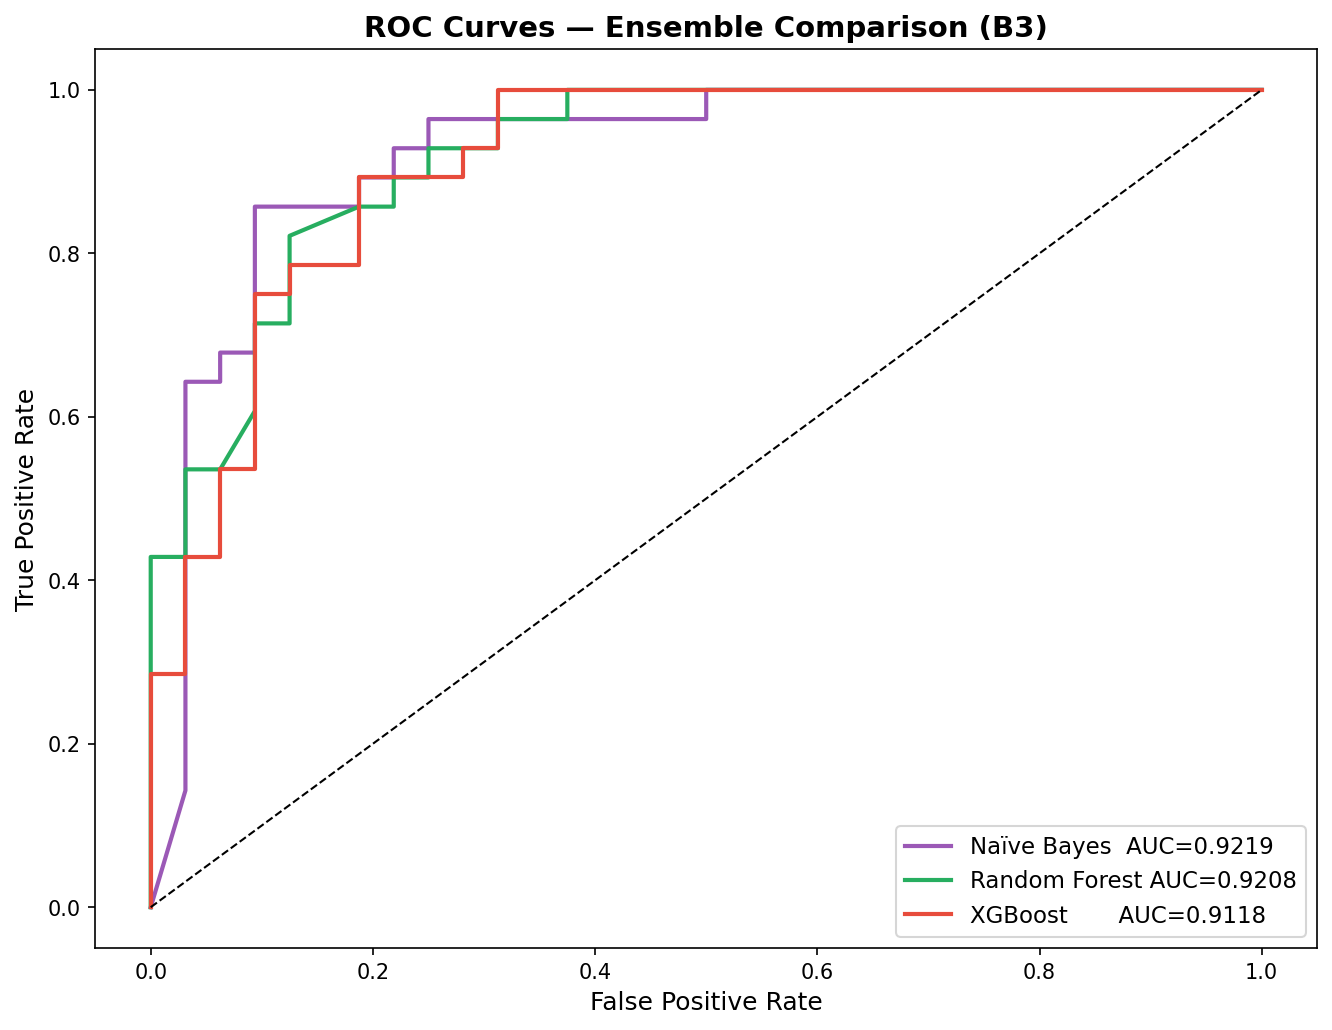

In [29]:
auc_nb  = round(roc_auc_score(y_te, y_prob_nb),  4)
auc_rf  = round(roc_auc_score(y_te, y_prob_rf),  4)
auc_xgb = round(roc_auc_score(y_te, y_prob_xgb), 4)

fig, ax = plt.subplots(figsize=(9, 7))
for prob, name, auc, col in [
        (y_prob_nb,  f'Naïve Bayes  AUC={auc_nb}',  auc_nb,  '#9B59B6'),
        (y_prob_rf,  f'Random Forest AUC={auc_rf}',  auc_rf,  '#27AE60'),
        (y_prob_xgb, f'XGBoost       AUC={auc_xgb}', auc_xgb, '#E74C3C')]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    ax.plot(fpr, tpr, lw=2, color=col, label=name)

ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Ensemble Comparison (B3)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('diagrams/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/roc_curves.png"))


### Part C: Artificial Neural Networks on Tabular Data

#### <small>C1 · Single-Layer Perceptron (SLP)</small>

In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

n_feats = X_tr.shape[1]

slp = keras.Sequential([
    layers.Input(shape=(n_feats,)),
    layers.Dense(1, activation='sigmoid')
])
slp.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
             loss='binary_crossentropy', metrics=['accuracy'])

slp_hist = slp.fit(X_tr, y_tr, epochs=100, batch_size=32, verbose=0)


#### <small>C1 · SLP training curves</small>

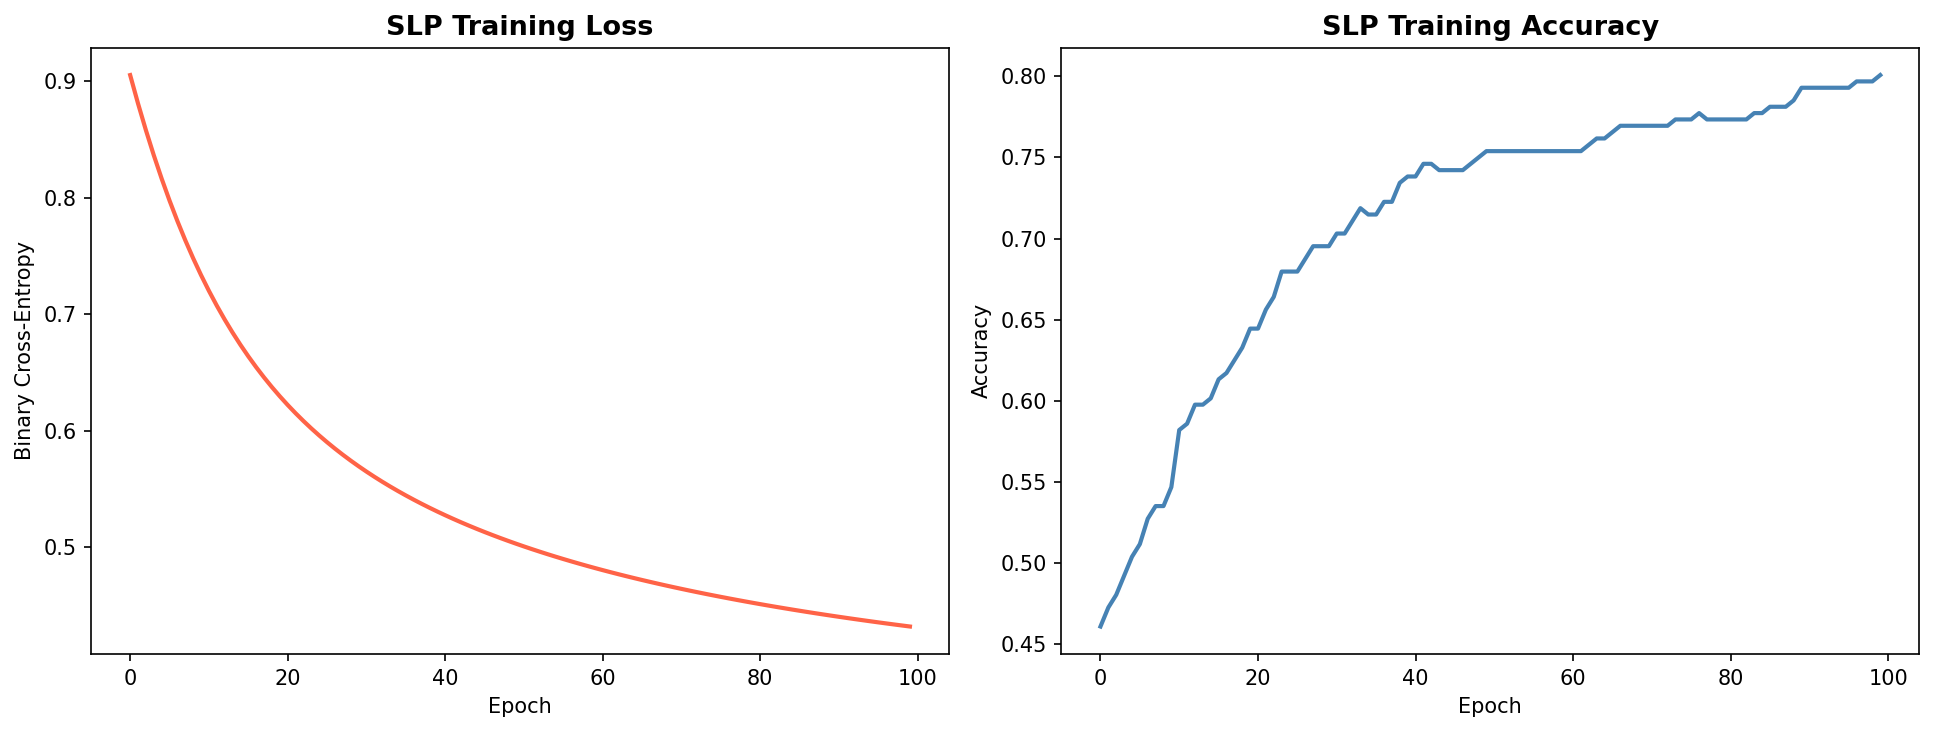

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(slp_hist.history['loss'],     color='tomato',    lw=2)
axes[0].set_title('SLP Training Loss',     fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy')
axes[1].plot(slp_hist.history['accuracy'], color='steelblue', lw=2)
axes[1].set_title('SLP Training Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig('diagrams/slp_curves.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/slp_curves.png"))


#### <small>C1 · SLP top weights · Metrics · Confusion matrix</small>

,Feature,Abs. Weight,Signed Weight
0,oldpeak,0.567200,0.567200
1,cp_4.0,0.467000,0.467000
2,ca,0.463200,0.463200


,precision,recall,f1-score,support
No Disease,0.848500,0.875000,0.861500,32.000000
Disease,0.851900,0.821400,0.836400,28.000000
accuracy,0.850000,0.850000,0.850000,0.850000
macro avg,0.850200,0.848200,0.849000,60.000000
weighted avg,0.850100,0.850000,0.849800,60.000000


AUC-ROC: 0.9297


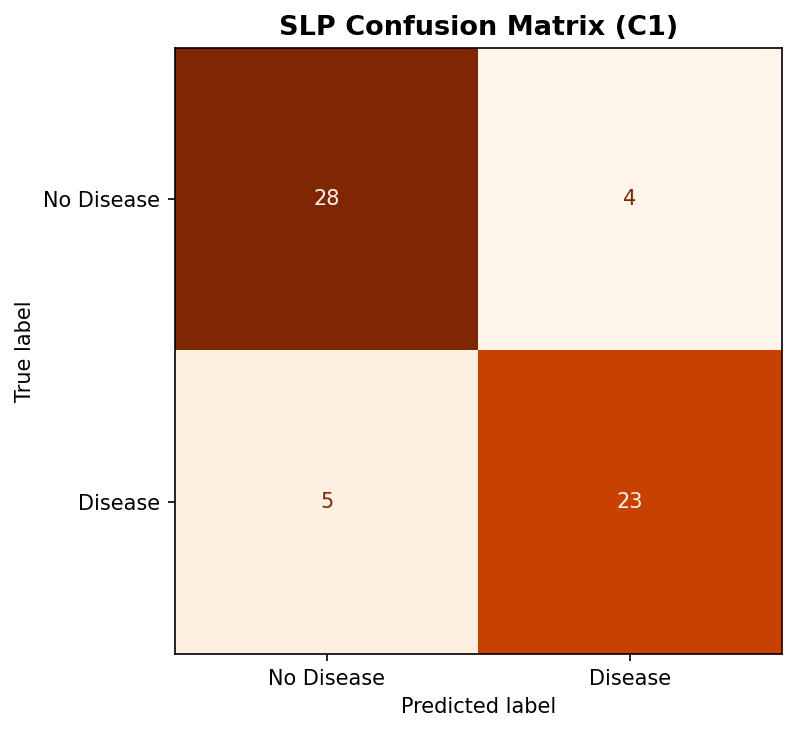

In [32]:
slp_weights = slp.layers[0].get_weights()[0].flatten()
abs_w = np.abs(slp_weights)
top3_idx = np.argsort(abs_w)[::-1][:3]

w_df = pd.DataFrame({'Feature':        [feat_names[i] for i in top3_idx],
                      'Abs. Weight':    [round(abs_w[i], 4) for i in top3_idx],
                      'Signed Weight':  [round(slp_weights[i], 4) for i in top3_idx]})
display(w_df.style.set_caption("C1: SLP — Top 3 Features by Absolute Weight")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))

y_prob_slp = slp.predict(X_te, verbose=0).flatten()
y_pred_slp = (y_prob_slp >= 0.5).astype(int)

report_slp = classification_report(y_te, y_pred_slp,
                                    target_names=['No Disease','Disease'],
                                    output_dict=True)
display(pd.DataFrame(report_slp).T.round(4).style.set_caption(
    "C1: SLP Classification Report")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))
print(f"AUC-ROC: {roc_auc_score(y_te, y_prob_slp):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_slp),
                       display_labels=['No Disease','Disease']).plot(
    ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('SLP Confusion Matrix (C1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/slp_cm.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/slp_cm.png"))


#### <small>C2 · MLP — three architecture comparison</small>

In [33]:
tf.random.set_seed(42)
np.random.seed(42)

def build_mlp(layer_sizes, dropout_rate=0.0, activation='relu'):
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_feats,)))
    for size in layer_sizes:
        model.add(layers.Dense(size, activation=activation,
                               kernel_regularizer=keras.regularizers.l2(1e-4)))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

arch_configs = [
    ([32],          0.0,  'relu',  'Small  (32)'),
    ([64, 32],      0.3,  'relu',  'Medium (64→32)'),
    ([128, 64, 32], 0.3,  'relu',  'Large  (128→64→32)'),
]
arch_results = []

for sizes, dr, act, name in arch_configs:
    m = build_mlp(sizes, dr, act)
    t0 = time.time()
    m.fit(X_tr, y_tr, epochs=150, batch_size=32, verbose=0,
          validation_split=0.2,
          callbacks=[keras.callbacks.EarlyStopping(
              patience=10, restore_best_weights=True, monitor='val_loss')])
    elapsed = round(time.time() - t0, 1)
    yp = (m.predict(X_te, verbose=0).flatten() >= 0.5).astype(int)
    arch_results.append({'Architecture': name,
                         'Hidden Layers': str(sizes),
                         'Dropout': dr,
                         'Val F1 (Test)': round(f1_score(y_te, yp, average='macro'), 4),
                         'Train Time (s)': elapsed})

display(pd.DataFrame(arch_results).style
        .set_caption("C2: MLP Architecture Comparison")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ])
        .highlight_max(subset=['Val F1 (Test)'], color='lightgreen'))


,Architecture,Hidden Layers,Dropout,Val F1 (Test),Train Time (s)
0,Small (32),[32],0.000000,0.849000,25.300000
1,Medium (64→32),"[64, 32]",0.300000,0.812400,27.700000
2,Large (128→64→32),"[128, 64, 32]",0.300000,0.831600,17.700000


#### <small>C2 · Best MLP — full training with early stopping</small>

Early stopping triggered at epoch: 15


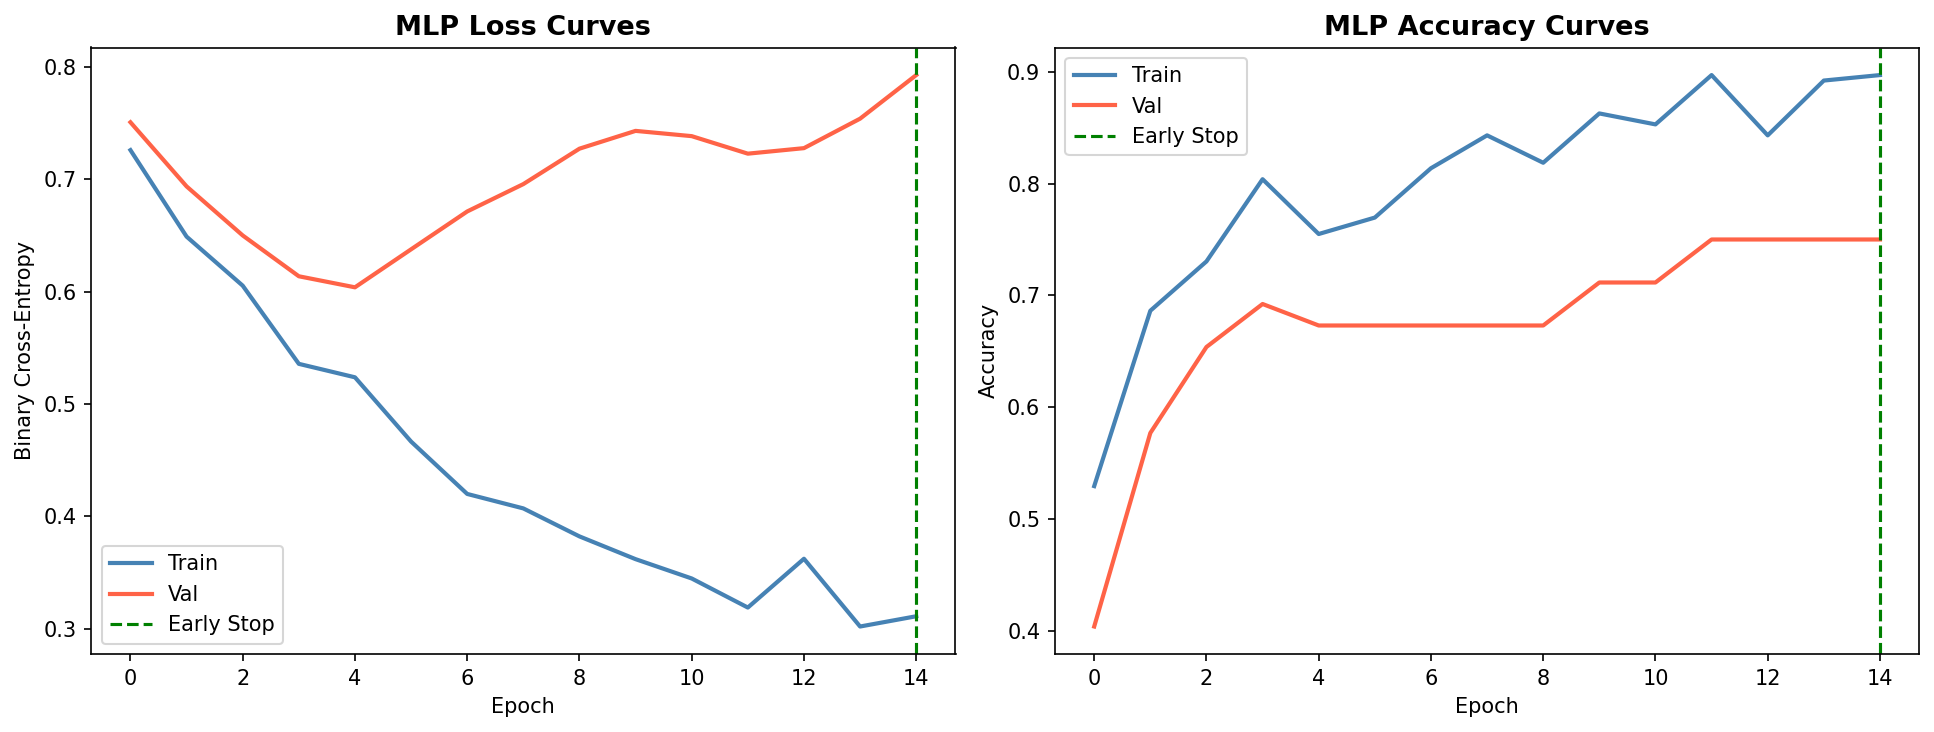

In [34]:
tf.random.set_seed(42)
np.random.seed(42)

mlp_best = build_mlp([128, 64, 32], dropout_rate=0.3, activation='relu')
es_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')

mlp_hist = mlp_best.fit(X_tr, y_tr, epochs=200, batch_size=32, verbose=0,
                          validation_split=0.2, callbacks=[es_cb])
stopped_at = len(mlp_hist.history['loss'])
print(f"Early stopping triggered at epoch: {stopped_at}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (key, title, ylabel) in enumerate([
        ('loss','MLP Loss Curves','Binary Cross-Entropy'),
        ('accuracy','MLP Accuracy Curves','Accuracy')]):
    axes[i].plot(mlp_hist.history[key],        color='steelblue', lw=2, label='Train')
    axes[i].plot(mlp_hist.history[f'val_{key}'], color='tomato',  lw=2, label='Val')
    axes[i].axvline(x=stopped_at-1, color='green', ls='--', lw=1.5, label='Early Stop')
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Epoch'); axes[i].set_ylabel(ylabel)
    axes[i].legend()
plt.tight_layout()
plt.savefig('diagrams/mlp_curves.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/mlp_curves.png"))


#### <small>C2 · 5-fold cross-validation on training set</small>

In [35]:
# C2 · 5-fold cross-validation on training set
# FIX: build model outside the predict call to avoid retracing warnings
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accs, fold_f1s = [], []

for fold_num, (fold_tr_idx, fold_val_idx) in enumerate(skf.split(X_tr, y_tr), 1):
    tf.random.set_seed(42)
    fm = build_mlp([128, 64, 32], dropout_rate=0.3)
    fm.fit(
        X_tr[fold_tr_idx], y_tr[fold_tr_idx],
        epochs=100, batch_size=32, verbose=0,
        validation_data=(X_tr[fold_val_idx], y_tr[fold_val_idx]),
        callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
    )
    # Batch predict to avoid retracing
    probs = fm.predict(X_tr[fold_val_idx], verbose=0, batch_size=64).flatten()
    yp    = (probs >= 0.5).astype(int)
    fold_accs.append(accuracy_score(y_tr[fold_val_idx], yp))
    fold_f1s.append(f1_score(y_tr[fold_val_idx], yp, average="macro"))
    print(f"  Fold {fold_num}/5 — Acc: {fold_accs[-1]:.4f}  F1: {fold_f1s[-1]:.4f}")
    keras.backend.clear_session()   # free memory between folds

cv_df = pd.DataFrame({
    "Metric":   ["Accuracy", "Macro F1"],
    "Mean":     [round(float(np.mean(fold_accs)), 4), round(float(np.mean(fold_f1s)), 4)],
    "Std (±)":  [round(float(np.std(fold_accs)),  4), round(float(np.std(fold_f1s)),  4)],
})

display(cv_df.style
    .set_caption("C2: 5-Fold Cross-Validation Results (MLP Large)")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props":    [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props":    [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props":    [("background","#f2f6fb")]},
    ])
)


  Fold 1/5 — Acc: 0.8462  F1: 0.8459

  Fold 2/5 — Acc: 0.8824  F1: 0.8823
  Fold 3/5 — Acc: 0.7647  F1: 0.7646
  Fold 4/5 — Acc: 0.8039  F1: 0.8038
  Fold 5/5 — Acc: 0.8627  F1: 0.8619


,Metric,Mean,Std (±)
0,Accuracy,0.832000,0.042400
1,Macro F1,0.831700,0.042300


#### <small>C2 · MLP final evaluation metrics + confusion matrix</small>

,precision,recall,f1-score,support
No Disease,0.833300,0.937500,0.882400,32.000000
Disease,0.916700,0.785700,0.846200,28.000000
accuracy,0.866700,0.866700,0.866700,0.866700
macro avg,0.875000,0.861600,0.864300,60.000000
weighted avg,0.872200,0.866700,0.865500,60.000000


AUC-ROC: 0.9196


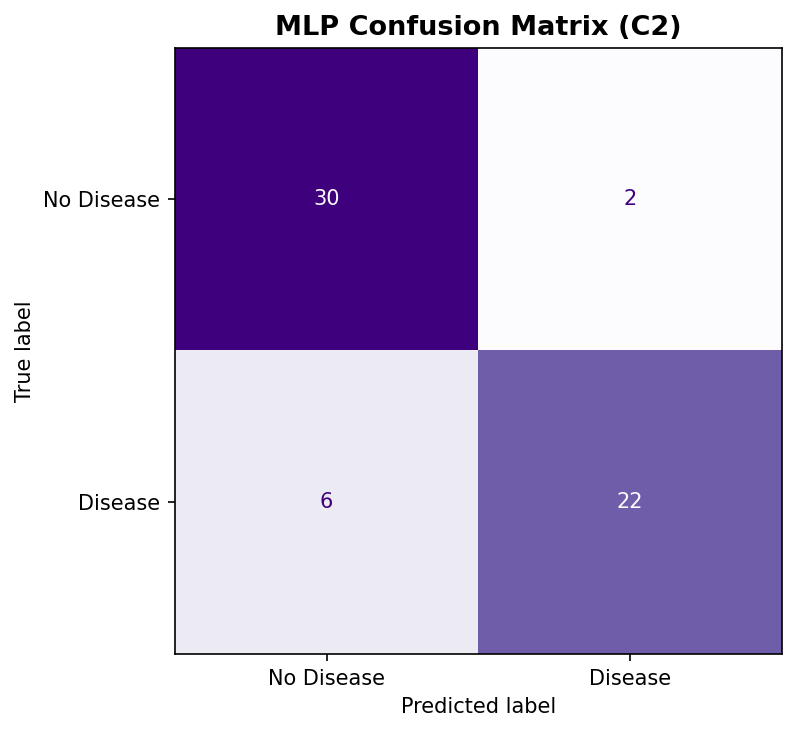

In [36]:
y_prob_mlp = mlp_best.predict(X_te, verbose=0).flatten()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

display(pd.DataFrame(
    classification_report(y_te, y_pred_mlp,
                          target_names=['No Disease','Disease'],
                          output_dict=True)).T.round(4).style.set_caption(
    "C2: MLP Classification Report")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))
print(f"AUC-ROC: {roc_auc_score(y_te, y_prob_mlp):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_mlp),
                       display_labels=['No Disease','Disease']).plot(
    ax=ax, cmap='Purples', colorbar=False)
ax.set_title('MLP Confusion Matrix (C2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/mlp_cm.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/mlp_cm.png"))


#### <small>C3 · Ablation study — three reduced variants</small>

In [37]:
tf.random.set_seed(42)
np.random.seed(42)

def eval_variant(model, hist=None, fixed_epochs=None):
    yp  = (model.predict(X_te, verbose=0).flatten() >= 0.5).astype(int)
    f1  = round(f1_score(y_te, yp, average='macro'), 4)
    vl  = round(min(hist.history['val_loss']), 4) if hist else '—'
    ep  = len(hist.history['loss']) if hist else fixed_epochs
    return f1, vl, ep

ablation = []

# Baseline
f1_b, vl_b, ep_b = eval_variant(mlp_best, mlp_hist)
ablation.append({'Variant': 'Baseline (best MLP)', 'Test F1': f1_b,
                 'Min Val Loss': vl_b, 'Epochs Run': ep_b})

# Variant A — No Dropout
vA = keras.Sequential([
    layers.Input(shape=(n_feats,)),
    layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dense(64,  activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dense(32,  activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dense(1,   activation='sigmoid')
])
vA.compile(optimizer=keras.optimizers.Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
hA = vA.fit(X_tr, y_tr, epochs=200, batch_size=32, verbose=0,
             validation_split=0.2,
             callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
f1A, vlA, epA = eval_variant(vA, hA)
ablation.append({'Variant': 'A: No Dropout', 'Test F1': f1A, 'Min Val Loss': vlA, 'Epochs Run': epA})

# Variant B — Sigmoid activation
vB = build_mlp([128, 64, 32], dropout_rate=0.3, activation='sigmoid')
hB = vB.fit(X_tr, y_tr, epochs=200, batch_size=32, verbose=0,
             validation_split=0.2,
             callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
f1B, vlB, epB = eval_variant(vB, hB)
ablation.append({'Variant': 'B: Sigmoid Activation', 'Test F1': f1B, 'Min Val Loss': vlB, 'Epochs Run': epB})

# Variant C — No early stopping (fixed 150 epochs)
vC = build_mlp([128, 64, 32], dropout_rate=0.3)
hC = vC.fit(X_tr, y_tr, epochs=150, batch_size=32, verbose=0, validation_split=0.2)
f1C, vlC, epC = eval_variant(vC, hC)
ablation.append({'Variant': 'C: No Early Stopping (150 ep)', 'Test F1': f1C, 'Min Val Loss': vlC, 'Epochs Run': epC})

display(pd.DataFrame(ablation).style
        .set_caption("C3: Ablation Study Results")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ])
        .highlight_max(subset=['Test F1'], color='lightgreen')
        .highlight_min(subset=['Min Val Loss'], color='lightblue'))


,Variant,Test F1,Min Val Loss,Epochs Run
0,Baseline (best MLP),0.864300,0.603800,15
1,A: No Dropout,0.862900,0.668800,14
2,B: Sigmoid Activation,0.847900,0.620000,37
3,C: No Early Stopping (150 ep),0.816200,0.632300,150


### Part D: CNN on MNIST Digits

#### <small>D1 · Data preparation + MLP baseline</small>

In [ ]:
from keras.datasets import mnist
from keras.utils    import to_categorical

(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()

x_train_sub = x_train_full[:12000]
y_train_sub = y_train_full[:12000]
x_test_sub  = x_test_full[:2000]
y_test_sub  = y_test_full[:2000]

x_train_norm = x_train_sub.astype('float32') / 255.0
x_test_norm  = x_test_sub.astype('float32')  / 255.0

x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test_norm.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train_sub, 10)
y_test_cat  = to_categorical(y_test_sub,  10)

print("Train CNN:", x_train_cnn.shape, " | Test CNN:", x_test_cnn.shape)


Train CNN: (12000, 28, 28, 1)  | Test CNN: (2000, 28, 28, 1)


#### <small>D1 · 5×2 sample image grid (one per digit class)</small>

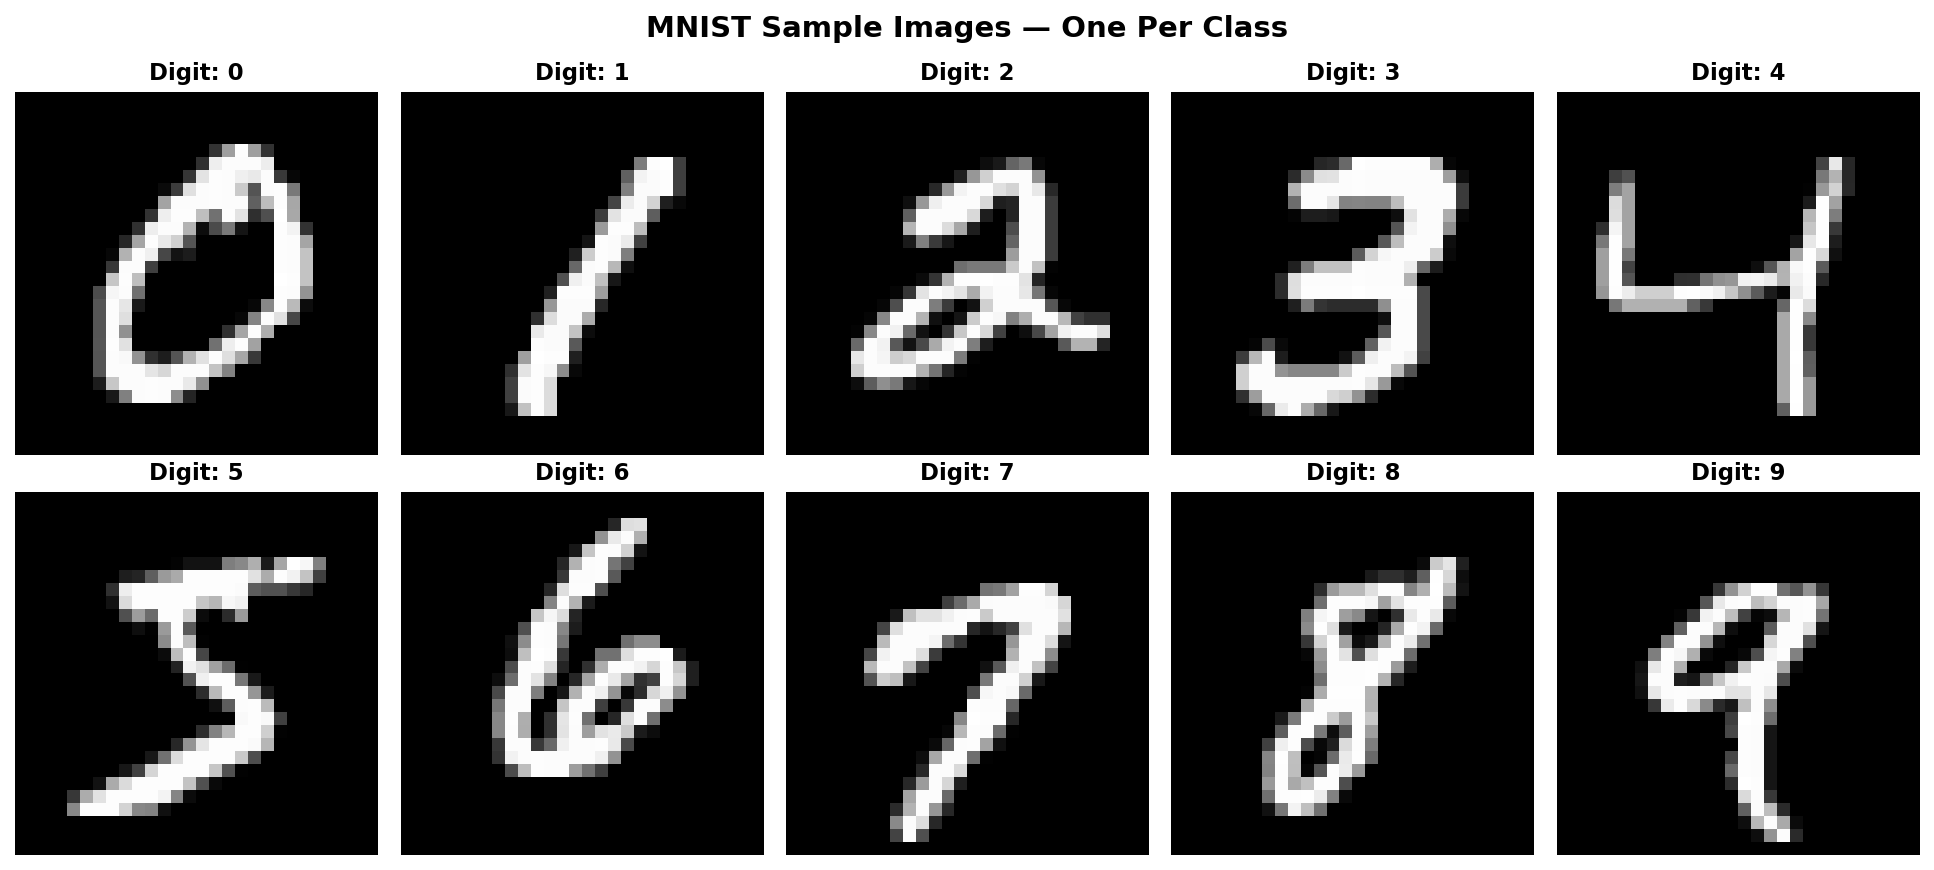

In [39]:
shown = {}
for i in range(len(x_train_sub)):
    d = y_train_sub[i]
    if d not in shown: shown[d] = x_train_sub[i]
    if len(shown) == 10: break

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for d in range(10):
    r, c = d // 5, d % 5
    axes[r][c].imshow(shown[d], cmap='gray')
    axes[r][c].set_title(f'Digit: {d}', fontsize=11, fontweight='bold')
    axes[r][c].axis('off')
plt.suptitle('MNIST Sample Images — One Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/mnist_samples.png"))


#### <small>D1 · MLP baseline (flattened, 5 epochs)</small>

In [40]:
tf.random.set_seed(42)

x_flat_train = x_train_norm.reshape(-1, 784)
x_flat_test  = x_test_norm.reshape(-1, 784)

mlp_base = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
mlp_base.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
mlp_base.fit(x_flat_train, y_train_sub, epochs=5, batch_size=64,
              verbose=1, validation_split=0.1)

_, mlp_test_acc = mlp_base.evaluate(x_flat_test, y_test_sub, verbose=0)
print(f"MLP Baseline Test Accuracy: {mlp_test_acc:.4f}")


Epoch 1/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8161 - loss: 0.7195 - val_accuracy: 0.8950 - val_loss: 0.3726
Epoch 2/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9154 - loss: 0.3109 - val_accuracy: 0.9142 - val_loss: 0.2964
Epoch 3/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9304 - loss: 0.2511 - val_accuracy: 0.9283 - val_loss: 0.2600
Epoch 4/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9415 - loss: 0.2114 - val_accuracy: 0.9392 - val_loss: 0.2352
Epoch 5/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9495 - loss: 0.1817 - val_accuracy: 0.9458 - val_loss: 0.2185
MLP Baseline Test Accuracy: 0.9090


#### <small>D2 · Lightweight CNN + data augmentation</small>

In [ ]:
tf.random.set_seed(42)

cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])
cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
             loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

#### <small>D2 · Train CNN · Plot curves · Compare to MLP baseline</small>

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.6445 - loss: 1.0679 - val_accuracy: 0.9285 - val_loss: 0.2529
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.8777 - loss: 0.4027 - val_accuracy: 0.9525 - val_loss: 0.1562
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.9089 - loss: 0.3015 - val_accuracy: 0.9635 - val_loss: 0.1173
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9178 - loss: 0.2553 - val_accuracy: 0.9655 - val_loss: 0.0986
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.9291 - loss: 0.2277 - val_accuracy: 0.9710 - val_loss: 0.0891
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.9316 - loss: 0.2155 - val_accuracy: 0.9710 - val_loss: 0.0786
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9374 - loss: 0.2029 - val_accuracy: 0.9780 - val_loss: 0.0648
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.9452 - loss: 0.1757 - 

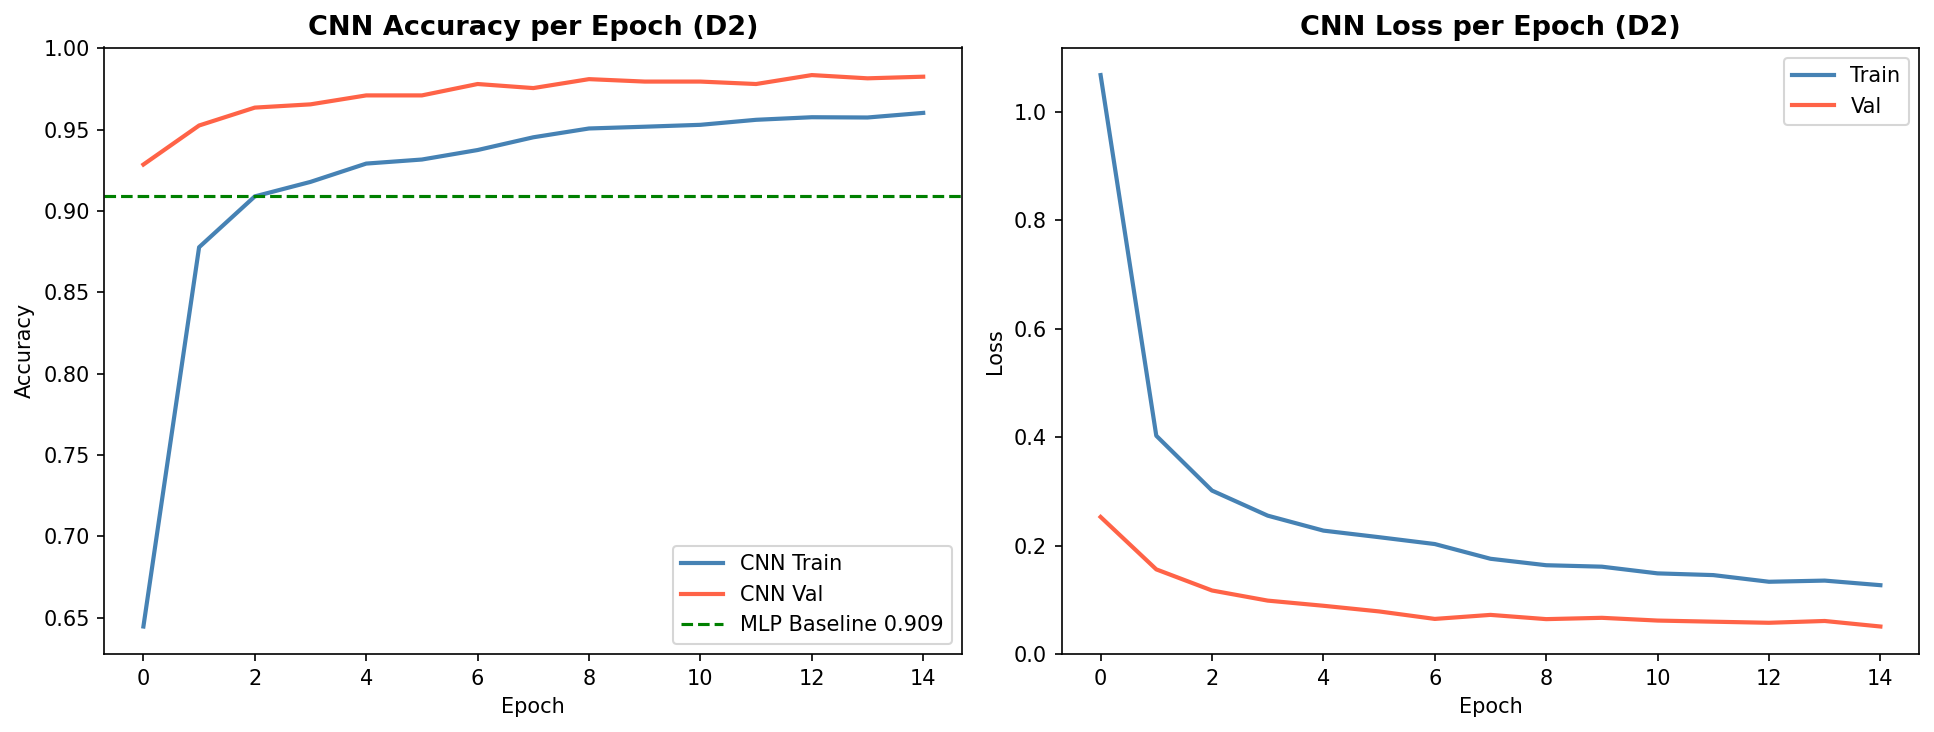

In [ ]:
cnn_hist = cnn.fit(x_train_cnn, y_train_cat,
                    batch_size=64,
                    epochs=15,
                    validation_data=(x_test_cnn, y_test_cat),
                    verbose=1)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(cnn_hist.history['accuracy'],     color='steelblue', lw=2, label='CNN Train')
axes[0].plot(cnn_hist.history['val_accuracy'], color='tomato',    lw=2, label='CNN Val')
axes[0].axhline(y=mlp_test_acc, color='green', ls='--', lw=1.5,
                label=f'MLP Baseline {mlp_test_acc:.3f}')
axes[0].set_title('CNN Accuracy per Epoch (D2)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(cnn_hist.history['loss'],     color='steelblue', lw=2, label='Train')
axes[1].plot(cnn_hist.history['val_loss'], color='tomato',    lw=2, label='Val')
axes[1].set_title('CNN Loss per Epoch (D2)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('diagrams/cnn_curves.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

_, cnn_test_acc = cnn.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"CNN Test Accuracy:  {cnn_test_acc:.4f}")
print(f"MLP Test Accuracy:  {mlp_test_acc:.4f}")

# Epoch where CNN first surpassed MLP baseline
for ep, acc in enumerate(cnn_hist.history['val_accuracy']):
    if acc > mlp_test_acc:
        print(f"CNN surpassed MLP baseline at epoch: {ep+1}")
        break

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/cnn_curves.png"))


#### <small>D2 · Confusion matrix heatmap · Most confused digit pairs</small>

,precision,recall,f1-score,support
0,0.994300,0.988600,0.991400,175.000000
1,1.000000,0.995700,0.997900,234.000000
2,0.981900,0.990900,0.986400,219.000000
3,0.985600,0.990300,0.988000,207.000000
4,0.986000,0.972400,0.979100,217.000000
5,0.962000,0.988800,0.975200,179.000000
6,0.977900,0.994400,0.986100,178.000000
7,0.985100,0.965900,0.975400,205.000000
8,0.989400,0.968800,0.978900,192.000000
9,0.959200,0.969100,0.964100,194.000000


Macro F1: 0.9822


,True,Predicted,Count
0,4,9,4
1,9,4,3
2,8,9,2
3,7,2,2
4,8,2,2


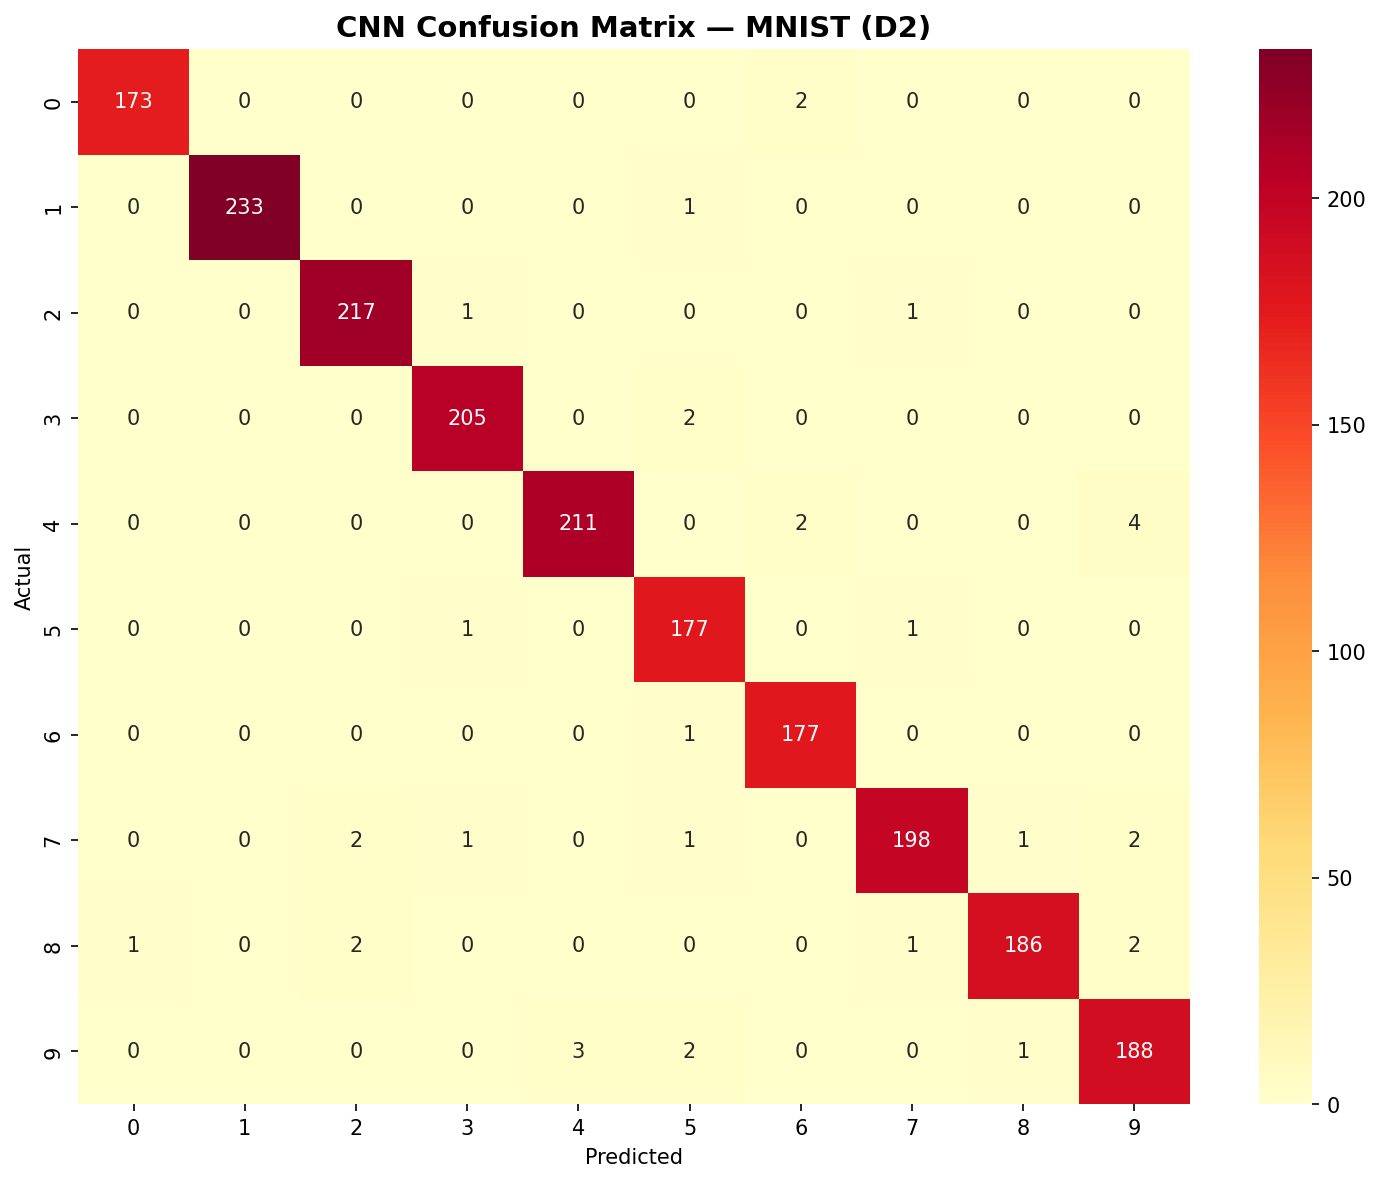

In [43]:
y_pred_cnn = np.argmax(cnn.predict(x_test_cnn, verbose=0), axis=1)

cnn_report = classification_report(y_test_sub, y_pred_cnn, output_dict=True)
cnn_report_df = pd.DataFrame(cnn_report).T.round(4)
display(cnn_report_df.style.set_caption("D2: CNN Classification Report (MNIST)")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))
print(f"Macro F1: {f1_score(y_test_sub, y_pred_cnn, average='macro'):.4f}")

cm_cnn = confusion_matrix(y_test_sub, y_pred_cnn)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_title('CNN Confusion Matrix — MNIST (D2)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('diagrams/cnn_cm.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

# ── Most confused pairs ──────────────────────────────────────────────────
cm_off = cm_cnn.copy()
np.fill_diagonal(cm_off, 0)
confused_pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            confused_pairs.append({'True': i, 'Predicted': j,
                                   'Count': cm_off[i, j]})
cp_df = pd.DataFrame(confused_pairs).sort_values('Count', ascending=False).head(5)
display(cp_df.reset_index(drop=True).style.set_caption(
    "D2: Top 5 Most Confused Digit Pairs")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("color","#1A5276")]},
        {"selector": "th",
         "props": [("background","#2C3E50"),("color","white"),("padding","8px 16px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background","#f2f6fb")]},
        {"selector": "td",
         "props": [("border","1px solid #dce6f0"),("padding","6px 14px")]},
    ]))

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/cnn_cm.png"))


#### <small>D3 · First Conv2D filter weights — 4×4 grid</small>

Filter shape: (3, 3, 1, 16)


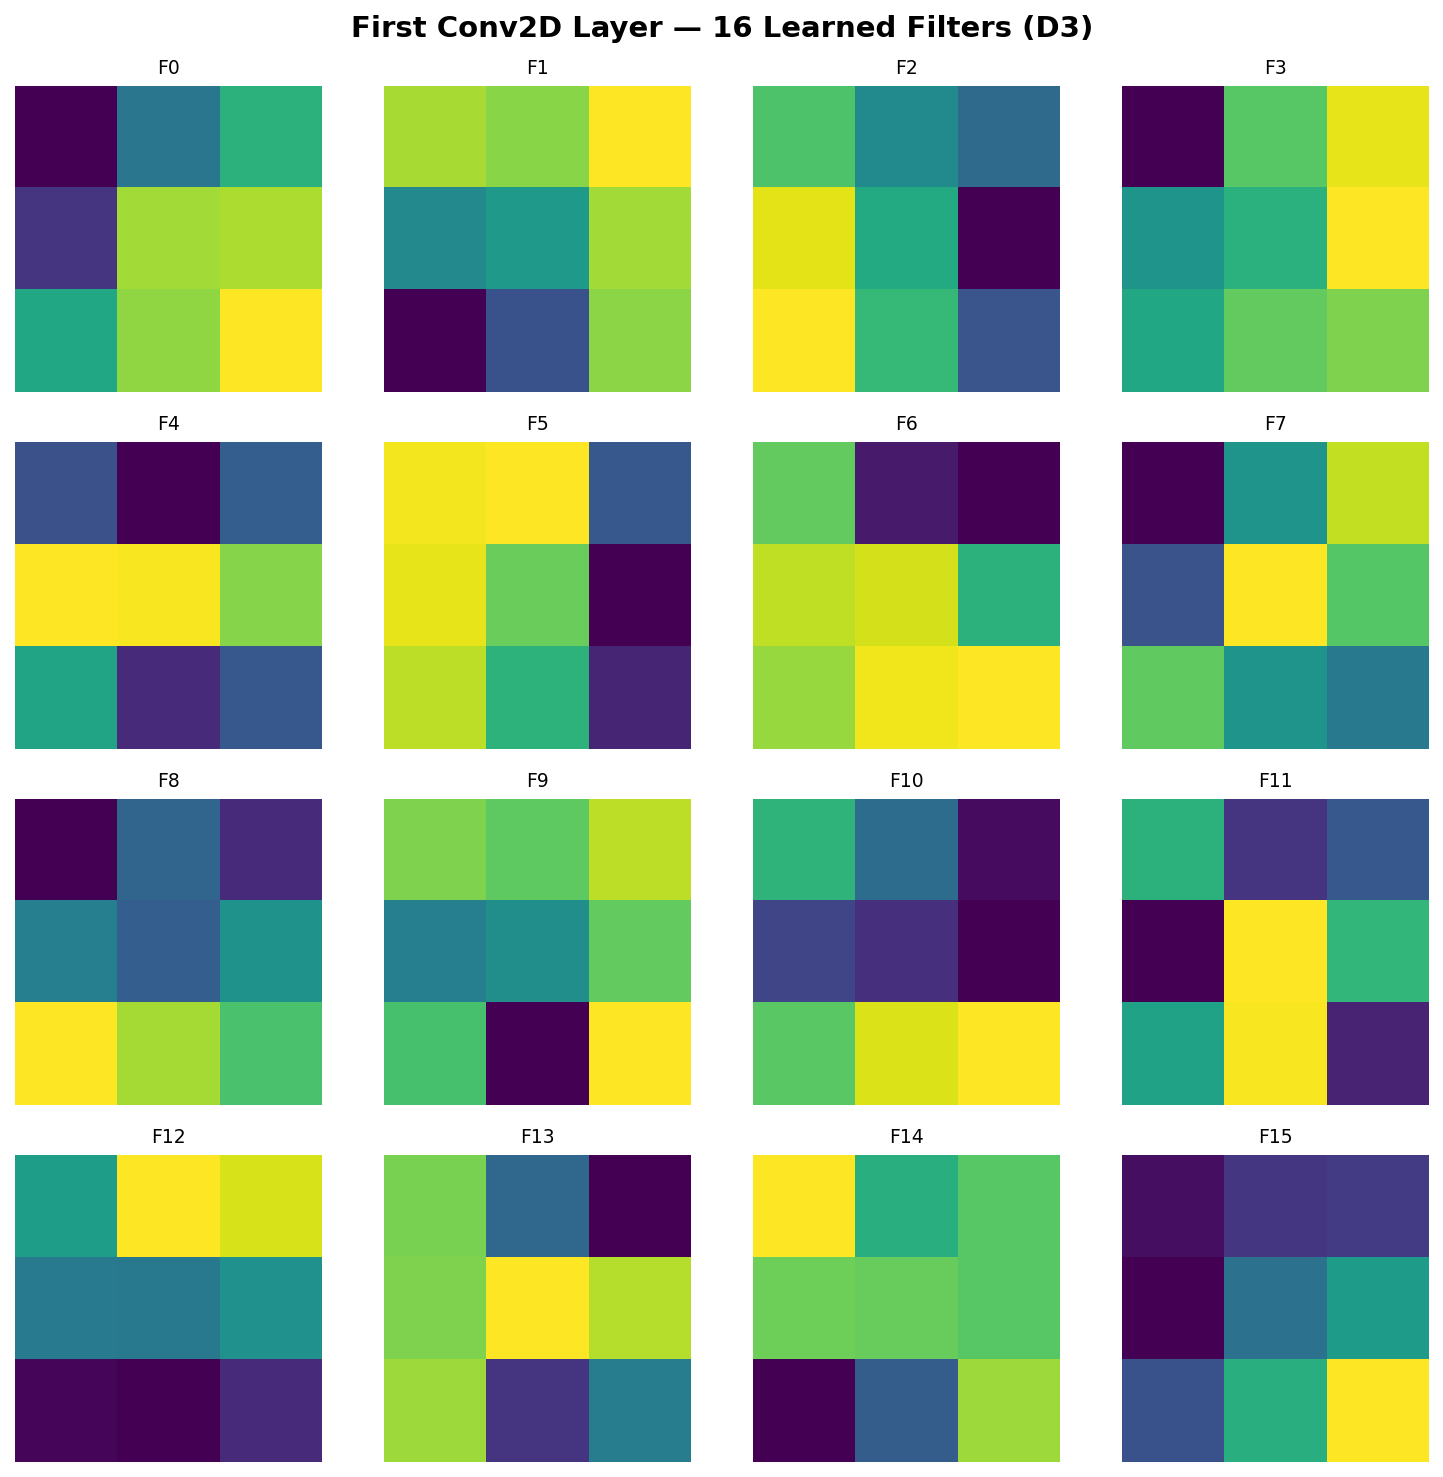

In [44]:
# FIX: cnn.layers[0] is InputLayer (no weights); Conv2D is layers[1]
conv1_layer = next(l for l in cnn.layers
                   if isinstance(l, layers.Conv2D))
first_layer_weights = conv1_layer.get_weights()[0]   # shape (3,3,1,16)
print("Filter shape:", first_layer_weights.shape)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i in range(16):
    r, c = i // 4, i % 4
    filt = first_layer_weights[:, :, 0, i]
    filt_norm = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
    axes[r][c].imshow(filt_norm, cmap='viridis')
    axes[r][c].set_title(f'F{i}', fontsize=9)
    axes[r][c].axis('off')
plt.suptitle('First Conv2D Layer — 16 Learned Filters (D3)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/cnn_filters.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/cnn_filters.png"))


#### <small>D3 · Feature maps from first Conv2D — 8 channels per digit class</small>

Feature map grid saved → diagrams/cnn_feature_maps.png


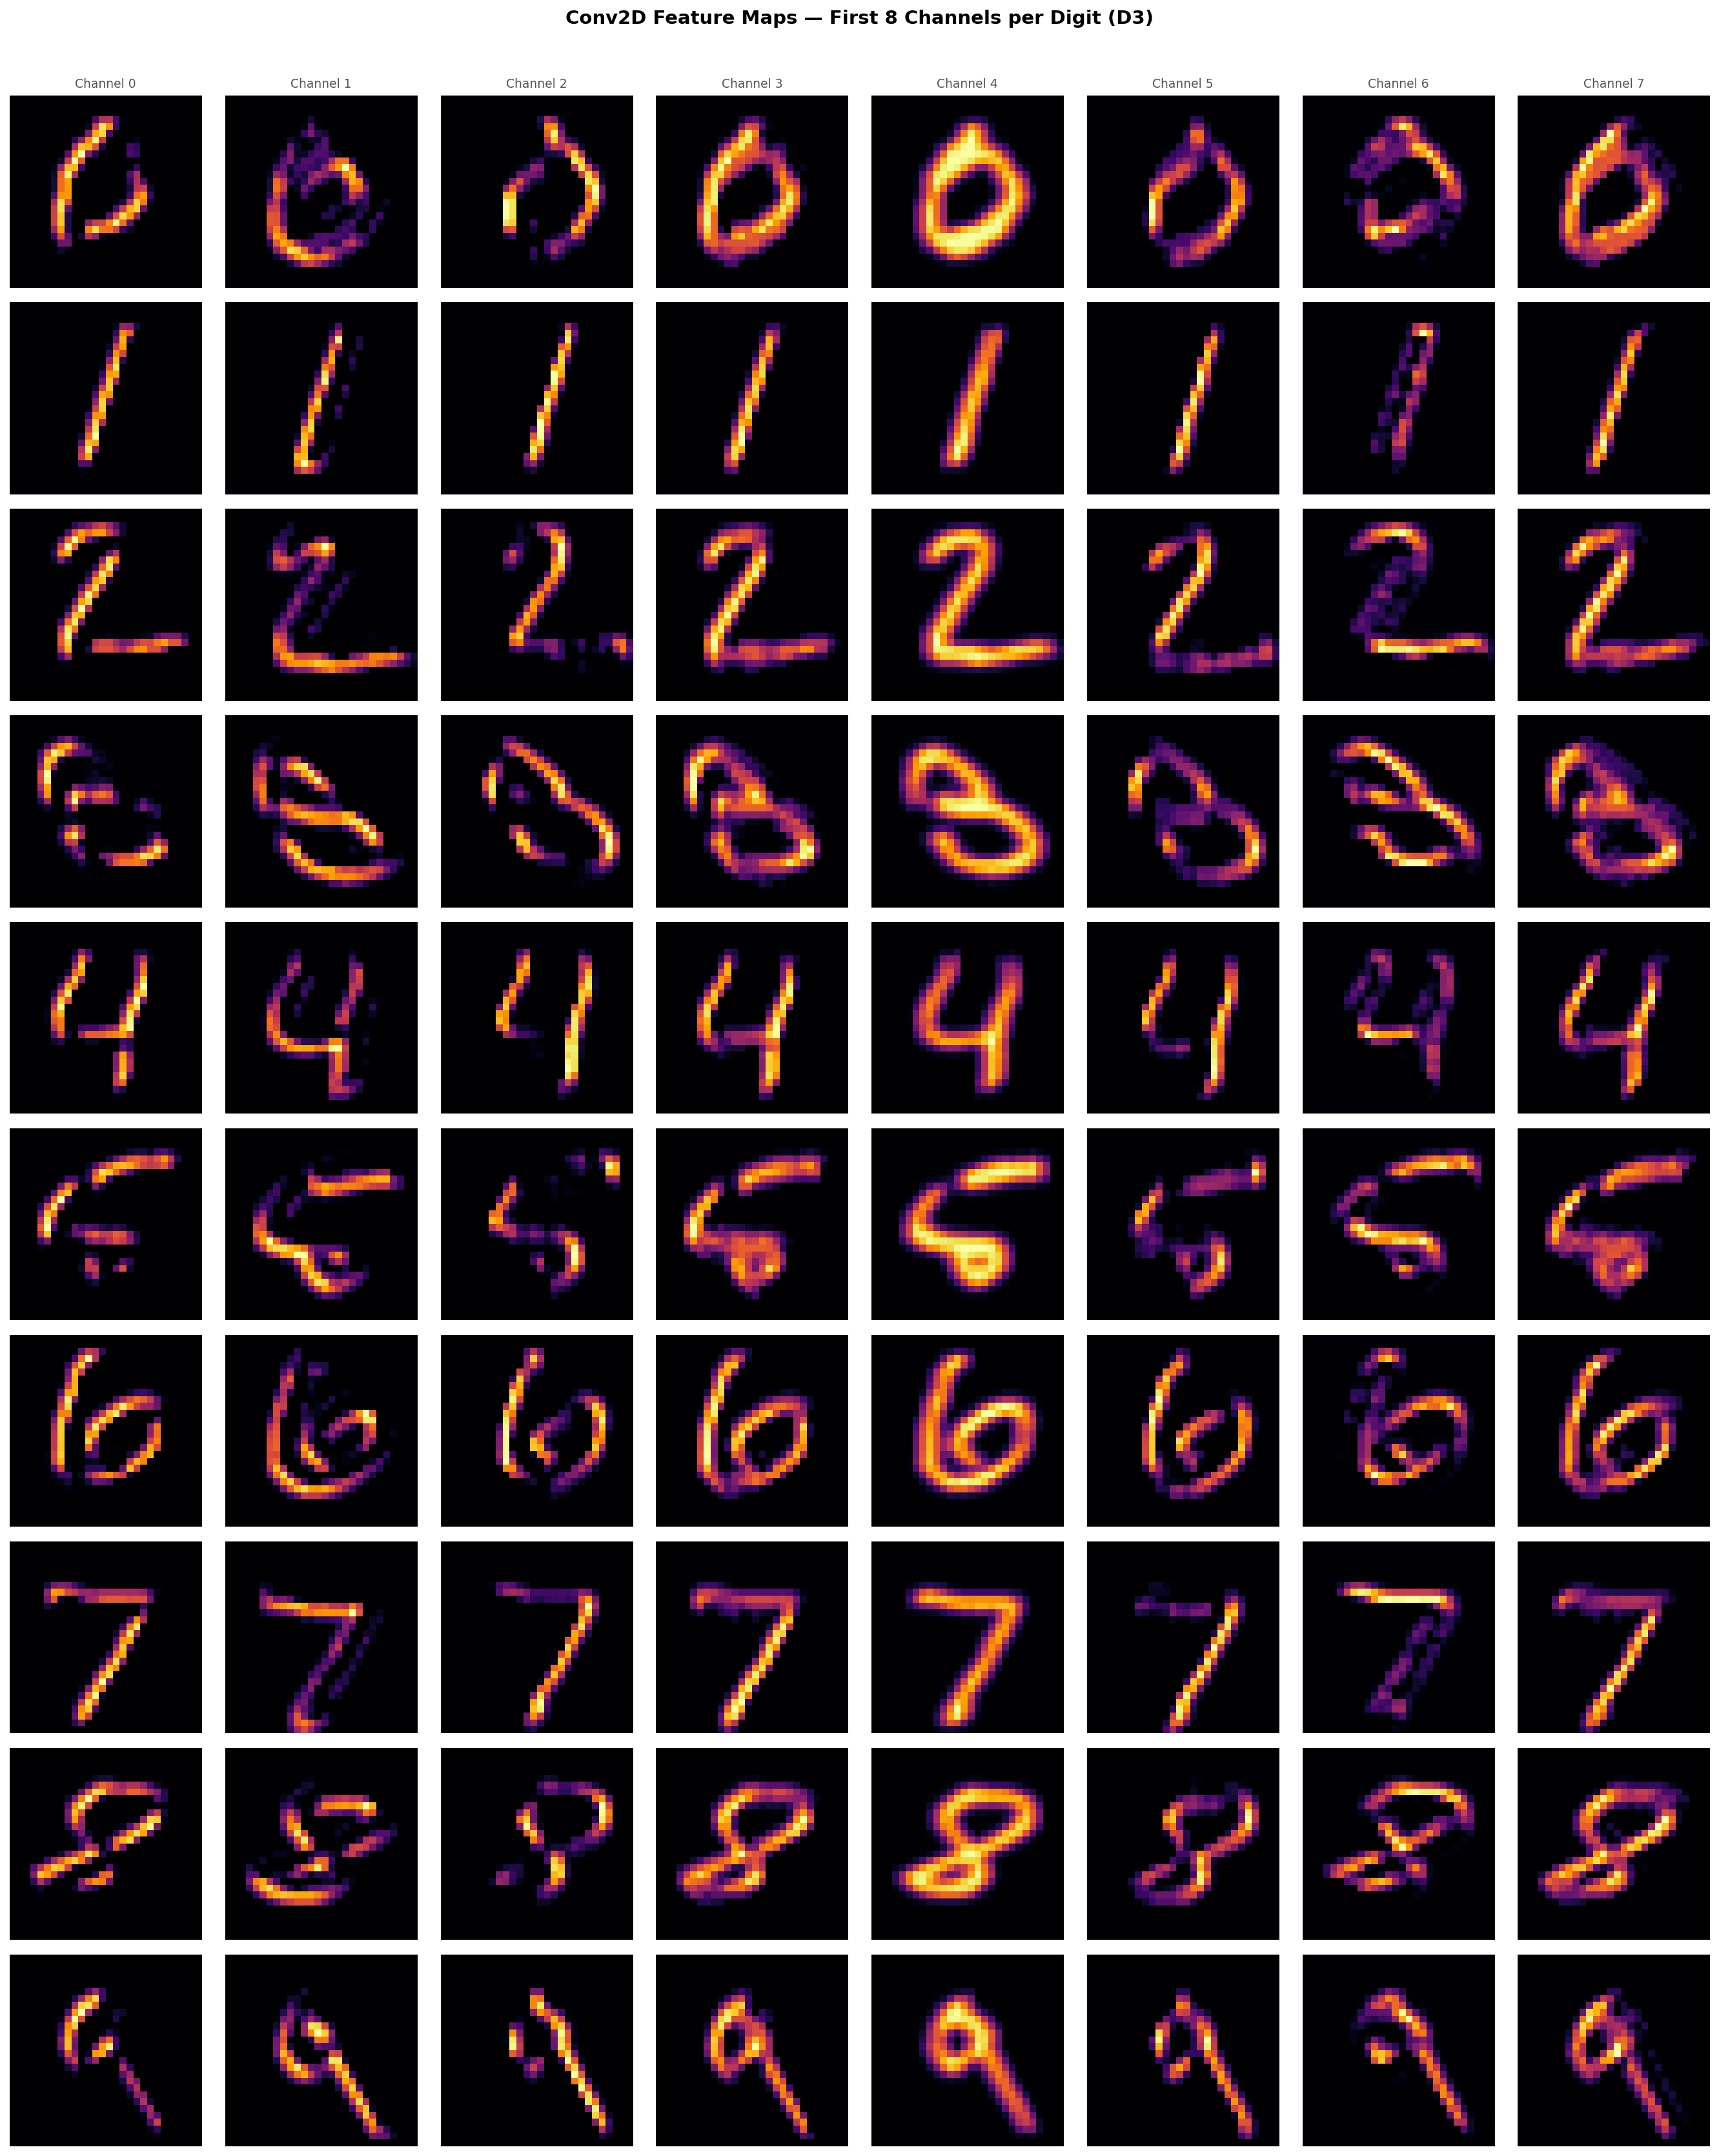

In [ ]:
from keras.models import Model
import IPython.display as ipd

# Keras 3 fix: use cnn.inputs[0] not cnn.input (avoids AttributeError)
feat_model = Model(inputs=cnn.inputs[0], outputs=conv1_layer.output)

# Collect one image per digit class
sample_images, sample_digits = [], []
for d in range(10):
    idx = np.where(y_test_sub == d)[0]
    if len(idx) > 0:
        sample_images.append(x_test_cnn[idx[0]])
        sample_digits.append(d)

# FIX retracing: batch all 10 predictions in ONE call instead of a loop of single calls
batch_input = np.stack(sample_images, axis=0)          # shape (10,28,28,1)
fmaps = feat_model.predict(batch_input, verbose=0)     # shape (10,14,14,16)

fig, big_axes = plt.subplots(10, 8, figsize=(18, 22))
for row_i in range(10):
    for ch in range(8):
        big_axes[row_i][ch].imshow(fmaps[row_i, :, :, ch], cmap="inferno")
        big_axes[row_i][ch].axis("off")
    big_axes[row_i][0].set_ylabel(f"Digit {sample_digits[row_i]}",
                                   fontsize=10, fontweight="bold")

# Column headers
for ch in range(8):
    big_axes[0][ch].set_title(f"Channel {ch}", fontsize=9, color="#555")

plt.suptitle("Conv2D Feature Maps — First 8 Channels per Digit (D3)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("diagrams/cnn_feature_maps.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Feature map grid saved → diagrams/cnn_feature_maps.png")

from IPython.display import Image, display as ipy_display
ipy_display(Image("diagrams/cnn_feature_maps.png"))


### Part E: Save Model Artifacts for Dashboard

In [46]:
# FIX: save raw (unencoded, unscaled) test patient so app.py gets real clinical values
sample_patient_raw = X_test.iloc[0].to_dict()

joblib.dump(rf_best,            'heart_model.pkl')
joblib.dump(scaler,             'scaler.pkl')
joblib.dump(feat_names,         'feature_names.pkl')
joblib.dump(sample_patient_raw, 'sample_patient.pkl')

print("Artifacts saved:")
print("  heart_model.pkl")
print("  scaler.pkl")
print("  feature_names.pkl")
print("  sample_patient.pkl")
print()
print("Raw sample patient values:")
for k, v in sample_patient_raw.items():
    print(f"  {k}: {v}")


Artifacts saved:
  heart_model.pkl
  scaler.pkl
  feature_names.pkl
  sample_patient.pkl

Raw sample patient values:
  age: 41.0
  sex: 1.0
  cp: 2.0
  trestbps: 120.0
  chol: 157.0
  fbs: 0.0
  restecg: 0.0
  thalach: 182.0
  exang: 0.0
  oldpeak: 0.0
  slope: 1.0
  ca: 0.0
  thal: 3.0
